# GloVe from first principles
### See the counts. Derive the objective. Learn the vectors.

This is a hands-on explanation for someone who knows Python, NumPy, linear algebra,
TF-IDF, LSA, and the basic idea of embeddings. Work downwards: each cell uses only
earlier definitions. All training data are included. No network requests or package
installations run inside this notebook; see `README.md` for setup.

The notebook follows the 26 sections in the requested learning path. Read the
**Knowledge check** cells before revealing the next **Answer** cell. The small
synthetic corpus is a microscope for the algorithm, not a semantic benchmark.
Default experiments use three fixed seeds and should take a few minutes on a CPU.

**Primary references:** [Pennington, Socher & Manning (2014), GloVe, §§3–4](https://aclanthology.org/D14-1162/),
[the authors' implementation and releases](https://nlp.stanford.edu/projects/glove/),
and [Mikolov et al. (2013), negative sampling](https://arxiv.org/abs/1310.4546).
The explanations below develop these ideas with our own tiny numerical examples.

## 1. Motivation: Why GloVe?

A **word embedding** assigns each vocabulary word a short real-valued vector.
Words used in similar environments may then have similar directions or useful
vector differences. Coordinates are learned features, not necessarily named concepts.

A word-count row has one coordinate per context word: it is large, sparse, and
affected by frequency. Two words can be related without appearing next to one another:
*king* and *queen* can both occur beside *rules*. TF-IDF downweights ubiquitous terms
but does not by itself learn shared latent features for different words. Its exact
word overlap remains brittle to synonyms. It is still a useful retrieval representation.

You already know the LSA route: compress a term-document matrix with SVD.
Skip-Gram instead learns vectors through a context prediction task on token windows.
GloVe first aggregates those windows over the entire corpus, then fits their statistics
with vector dot products. The window defines what counts as context; aggregation
makes the training statistics global. “Global” does not mean every word in a document
is a context word.

Why **ratios**? If *solid* is ten times as likely near *ice* as near *steam*, it distinguishes
them. *Water* may be frequent near both, so a ratio near one tells us less about their
difference. *Fashion* may be rare near both and also have a ratio near one. This is a
motivation, not a guarantee: ratios of sparse, noisy counts can be unreliable.
We will compute a deliberately illustrative version in Section 5.

In [1]:
from collections import Counter
from dataclasses import dataclass, replace
from pathlib import Path
from time import perf_counter
import platform
import re
import tempfile

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import torch
from IPython import get_ipython
from IPython.display import display, Markdown

get_ipython().run_line_magic("matplotlib", "inline")
torch.set_num_threads(1)  # Small tensors are faster without a large thread pool.
torch.use_deterministic_algorithms(True)
DTYPE = torch.float64  # Extra precision helps the numerical gradient check.
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})
pd.set_option("display.precision", 4)
display(pd.Series({"Python": platform.python_version(), "NumPy": np.__version__,
                   "pandas": pd.__version__, "matplotlib": matplotlib.__version__,
                   "PyTorch": torch.__version__}, name="runtime versions"))

Python            3.14.4
NumPy              2.5.3
pandas             3.0.5
matplotlib        3.11.1
PyTorch       2.14.0+cpu
Name: runtime versions, dtype: str

## 2. Build a Tiny Corpus

These 30 sentences deliberately reuse a few templates so we can inspect their counts.
Royalty, family, geography, pets, and physical states supply overlapping contexts.
The wording is synthetic; its associations are choices made by the author, not facts
discovered about society. We will not add sentences or select seeds to repair analogies.

**The configuration cell below is the control panel.** Edit it and restart/run all.
`max_vocab=None` retains every word; a positive cap keeps the most frequent words
(alphabetical tie breaking). The experiment grids are one-factor-at-a-time overrides.

In [2]:
CORPUS = (
    "the king rules the kingdom",
    "the queen rules the kingdom",
    "the king wears a crown",
    "the queen wears a crown",
    "the prince wears a crown",
    "the princess wears a crown",
    "the king is a man",
    "the queen is a woman",
    "the prince is a man",
    "the princess is a woman",
    "the man visits the palace",
    "the woman visits the palace",
    "the prince visits the king",
    "the princess visits the queen",
    "paris is in france",
    "berlin is in germany",
    "paris is a capital",
    "berlin is a capital",
    "the man visits paris",
    "the woman visits berlin",
    "the dog is a pet",
    "the cat is a pet",
    "the dog likes the man",
    "the cat likes the woman",
    "the dog plays with the cat",
    "the cat plays with the dog",
    "ice is solid water",
    "steam is water gas",
    "solid ice is cold",
    "steam gas is hot",
)

@dataclass(frozen=True)
class Config:
    corpus: tuple[str, ...] = CORPUS
    max_vocab: int | None = None
    window: int = 2
    dimension: int = 2
    learning_rate: float = 0.03
    epochs: int = 1000
    alpha: float = 0.75
    x_max: float = 5.0
    distance_weighting: bool = False
    seeds: tuple[int, ...] = (7, 17, 27)
    dimension_grid: tuple[int, ...] = (2, 5, 10, 20)
    window_grid: tuple[int, ...] = (1, 2, 4)
    alpha_grid: tuple[float, ...] = (0.5, 0.75, 1.0)
    x_max_grid: tuple[float, ...] = (1.0, 5.0, 10.0)
    distance_grid: tuple[bool, ...] = (False, True)

CONFIG = Config()
np.random.seed(CONFIG.seeds[0])
torch.manual_seed(CONFIG.seeds[0])

def tokenize(text):
    """Lowercase English alphabetic tokens; keep sentence boundaries externally."""
    return re.findall(r"[a-z]+", text.lower())

def build_vocabulary(sentences, max_vocab=None):
    """Select frequent words first, then assign alphabetical, reproducible IDs."""
    if max_vocab is not None and (not isinstance(max_vocab, int) or max_vocab < 1):
        raise ValueError("max_vocab must be None or a positive integer")
    frequencies = Counter(word for sentence in sentences for word in sentence)
    ranked = sorted(frequencies, key=lambda word: (-frequencies[word], word))
    vocabulary = sorted(ranked if max_vocab is None else ranked[:max_vocab])
    if not vocabulary:
        raise ValueError("The corpus contains no usable tokens")
    return vocabulary, {word: i for i, word in enumerate(vocabulary)}, frequencies

sentences = [tokenize(sentence) for sentence in CONFIG.corpus]
vocab, word_to_id, frequencies = build_vocabulary(sentences, CONFIG.max_vocab)
vocab_table = pd.DataFrame({"word": vocab, "index": range(len(vocab)),
                            "token frequency": [frequencies[w] for w in vocab]})
display(pd.DataFrame({"sentence": CONFIG.corpus,
                      "tokens": [" | ".join(s) for s in sentences]}))
display(vocab_table)
print("Vocabulary:", vocab)
print("word_to_id:", word_to_id)
print(f"{len(sentences)} sentences, {sum(map(len, sentences))} tokens, {len(vocab)} word types")

,sentence,tokens
0,the king rules the kingdom,the | king | rules | the | kingdom
1,the queen rules the kingdom,the | queen | rules | the | kingdom
2,the king wears a crown,the | king | wears | a | crown
3,the queen wears a crown,the | queen | wears | a | crown
4,the prince wears a crown,the | prince | wears | a | crown
5,the princess wears a crown,the | princess | wears | a | crown
6,the king is a man,the | king | is | a | man
7,the queen is a woman,the | queen | is | a | woman
8,the prince is a man,the | prince | is | a | man
9,the princess is a woman,the | princess | is | a | woman


,word,index,token frequency
0,a,0,12
1,berlin,1,3
2,capital,2,2
3,cat,3,4
4,cold,4,1
5,crown,5,4
6,dog,6,4
7,france,7,1
8,gas,8,2
9,germany,9,1


Vocabulary: ['a', 'berlin', 'capital', 'cat', 'cold', 'crown', 'dog', 'france', 'gas', 'germany', 'hot', 'ice', 'in', 'is', 'king', 'kingdom', 'likes', 'man', 'palace', 'paris', 'pet', 'plays', 'prince', 'princess', 'queen', 'rules', 'solid', 'steam', 'the', 'visits', 'water', 'wears', 'with', 'woman']
word_to_id: {'a': 0, 'berlin': 1, 'capital': 2, 'cat': 3, 'cold': 4, 'crown': 5, 'dog': 6, 'france': 7, 'gas': 8, 'germany': 9, 'hot': 10, 'ice': 11, 'in': 12, 'is': 13, 'king': 14, 'kingdom': 15, 'likes': 16, 'man': 17, 'palace': 18, 'paris': 19, 'pet': 20, 'plays': 21, 'prince': 22, 'princess': 23, 'queen': 24, 'rules': 25, 'solid': 26, 'steam': 27, 'the': 28, 'visits': 29, 'water': 30, 'wears': 31, 'with': 32, 'woman': 33}
30 sentences, 142 tokens, 34 word types


## 3. Context Windows

For target position $t$, a symmetric radius $r$ includes positions from $t-r$ to $t+r$,
clipped to the sentence, except $t$ itself. Here $t$ is a token position and $r$ is the
number of positions on **each** side, not the total number of context words.

In `the king rules the kingdom`, *king* is at position 1. Radius 1 gives *the* (0)
and *rules* (2); radius 2 adds *the* (3); radius 3 adds *kingdom* (4).
Two occurrences of *the* are two events. Left and right contexts are recorded
for inspection, then share the same context vocabulary in our matrix.

We visit each target position once. This already emits both directed pairs, such as
`king → rules` and `rules → king`; adding a second mirrored update would double count.

In [3]:
def context_pairs(tokens, window=2, distance_weighting=False):
    """Yield directed positional events within one sentence, excluding self-position."""
    if not isinstance(window, int) or window < 1:
        raise ValueError("window must be a positive integer")
    for target_position, target in enumerate(tokens):
        for context_position in range(max(0, target_position - window),
                                      min(len(tokens), target_position + window + 1)):
            if target_position == context_position:
                continue
            distance = abs(context_position - target_position)
            yield {"target position": target_position, "target": target,
                   "context position": context_position, "context": tokens[context_position],
                   "side": "left" if context_position < target_position else "right",
                   "distance": distance,
                   "contribution": 1.0 / distance if distance_weighting else 1.0}

example_tokens = tokenize("the king rules the kingdom")
for radius in (1, 2, 3):
    events = pd.DataFrame(context_pairs(example_tokens, radius))
    display(Markdown(f"**Radius {radius}: all {len(events)} directed events**"))
    display(events)
    display(Markdown("**Focus on king:** " + ", ".join(
        f"{row['context']} (position {row['context position']}, {row['side']})"
        for row in events.to_dict("records") if row["target"] == "king")))

**Radius 1: all 8 directed events**

,target position,target,context position,context,side,distance,contribution
0,0,the,1,king,right,1,1.0
1,1,king,0,the,left,1,1.0
2,1,king,2,rules,right,1,1.0
3,2,rules,1,king,left,1,1.0
4,2,rules,3,the,right,1,1.0
5,3,the,2,rules,left,1,1.0
6,3,the,4,kingdom,right,1,1.0
7,4,kingdom,3,the,left,1,1.0


**Focus on king:** the (position 0, left), rules (position 2, right)

**Radius 2: all 14 directed events**

,target position,target,context position,context,side,distance,contribution
0,0,the,1,king,right,1,1.0
1,0,the,2,rules,right,2,1.0
2,1,king,0,the,left,1,1.0
3,1,king,2,rules,right,1,1.0
4,1,king,3,the,right,2,1.0
5,2,rules,0,the,left,2,1.0
6,2,rules,1,king,left,1,1.0
7,2,rules,3,the,right,1,1.0
8,2,rules,4,kingdom,right,2,1.0
9,3,the,1,king,left,2,1.0


**Focus on king:** the (position 0, left), rules (position 2, right), the (position 3, right)

**Radius 3: all 18 directed events**

,target position,target,context position,context,side,distance,contribution
0,0,the,1,king,right,1,1.0
1,0,the,2,rules,right,2,1.0
2,0,the,3,the,right,3,1.0
3,1,king,0,the,left,1,1.0
4,1,king,2,rules,right,1,1.0
5,1,king,3,the,right,2,1.0
6,1,king,4,kingdom,right,3,1.0
7,2,rules,0,the,left,2,1.0
8,2,rules,1,king,left,1,1.0
9,2,rules,3,the,right,1,1.0


**Focus on king:** the (position 0, left), rules (position 2, right), the (position 3, right), kingdom (position 4, right)

**Knowledge check — pause here.** Does radius 2 always produce four contexts per target?

**Answer**

No. Sentence boundaries shorten the window. Repeated word types still count separately; the target position itself never counts.

## 4. Construct the Word Co-occurrence Matrix

Let $V$ be vocabulary size. The $V\times V$ matrix $X$ has target words in rows and
context words in columns. For uniform windows,

$$X_{ij}=\sum_{s}\sum_{t}\sum_{u:\,0<|u-t|\le r}
\mathbf{1}[s_t=i]\,\mathbf{1}[s_u=j].$$

Here $s$ indexes sentences, $t,u$ are valid positions **in that sentence**, $r$ is the
radius, and $\mathbf{1}$ is one when its condition holds, zero otherwise.
The vocabulary IDs $i,j$ identify word types. We sum contributions from all sentences.
For example, `king rules` contributes 1 to $X_{king,rules}$ and 1 to $X_{rules,king}$.
It does not contribute to either diagonal entry.

The audit below shows every changed matrix cell for every sentence. Contributions
to the same cell within a sentence are grouped, with their updated cumulative value.
This is an exact update trace without printing 30 mostly empty matrices.

**Sentence 1:** the king rules the kingdom

,target,context,increment,cumulative X_ij
0,king,rules,1.0,1.0
1,king,the,2.0,2.0
2,kingdom,rules,1.0,1.0
3,kingdom,the,1.0,1.0
4,rules,king,1.0,1.0
5,rules,kingdom,1.0,1.0
6,rules,the,2.0,2.0
7,the,king,2.0,2.0
8,the,kingdom,1.0,1.0
9,the,rules,2.0,2.0


**Sentence 2:** the queen rules the kingdom

,target,context,increment,cumulative X_ij
10,kingdom,rules,1.0,2.0
11,kingdom,the,1.0,2.0
12,queen,rules,1.0,1.0
13,queen,the,2.0,2.0
14,rules,kingdom,1.0,2.0
15,rules,queen,1.0,1.0
16,rules,the,2.0,4.0
17,the,kingdom,1.0,2.0
18,the,queen,2.0,2.0
19,the,rules,2.0,4.0


**Sentence 3:** the king wears a crown

...

**Sentence 29:** solid ice is cold

,target,context,increment,cumulative X_ij
332,cold,ice,1.0,1.0
333,cold,is,1.0,1.0
334,ice,cold,1.0,1.0
335,ice,is,1.0,2.0
336,ice,solid,1.0,2.0
337,is,cold,1.0,1.0
338,is,ice,1.0,2.0
339,is,solid,1.0,2.0
340,solid,ice,1.0,2.0
341,solid,is,1.0,2.0


**Sentence 30:** steam gas is hot

,target,context,increment,cumulative X_ij
342,gas,hot,1.0,1.0
343,gas,is,1.0,2.0
344,gas,steam,1.0,1.0
345,hot,gas,1.0,1.0
346,hot,is,1.0,1.0
347,is,gas,1.0,2.0
348,is,hot,1.0,1.0
349,is,steam,1.0,2.0
350,steam,gas,1.0,1.0
351,steam,is,1.0,2.0


,a,berlin,capital,cat,cold,crown,dog,france,gas,germany,hot,ice,in,is,king,kingdom,likes,man,palace,paris,pet,plays,prince,princess,queen,rules,solid,steam,the,visits,water,wears,with,woman
a,0.0,1.0,2.0,1.0,0.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,2.0,0.0,0.0,2.0,0.0,1.0,2.0,0.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,2.0
berlin,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
capital,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
cat,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,2.0,0.0
cold,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
crown,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0
dog,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,2.0,0.0
france,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
gas,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
germany,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


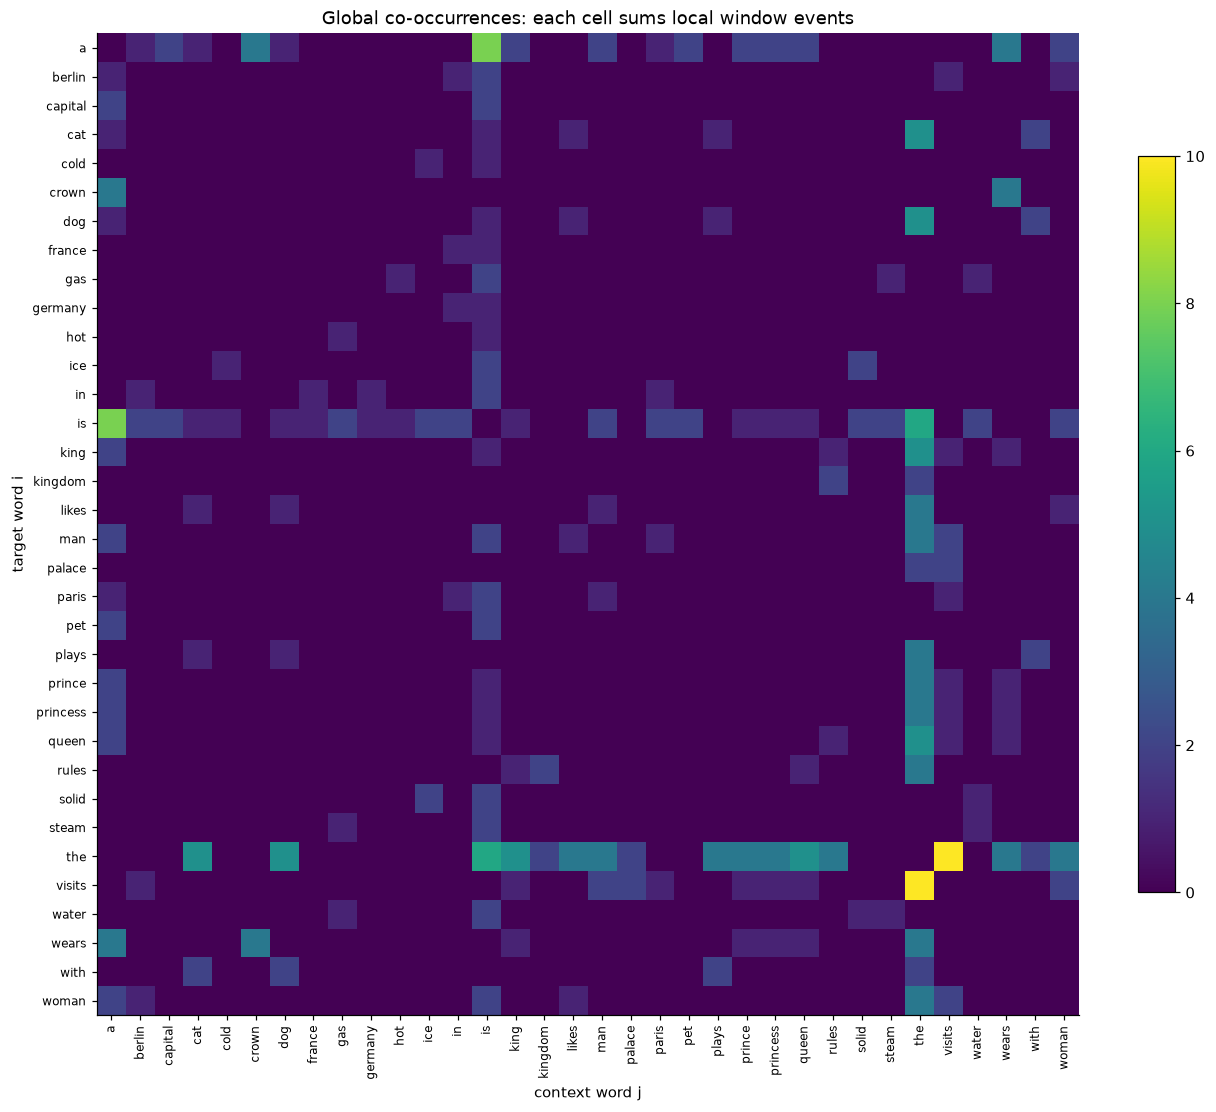

shape                 (34, 34)
observed entries           186
zero fraction           0.8391
symmetric                 True
total context mass       388.0
Name: matrix audit, dtype: object

In [4]:
def build_cooccurrence(sentences, word_to_id, window=2, distance_weighting=False,
                       return_trace=False):
    """Accumulate retained pairs without deleting OOV tokens or closing their gaps."""
    X = np.zeros((len(word_to_id), len(word_to_id)), dtype=np.float64)
    trace = []
    for sentence_number, tokens in enumerate(sentences, start=1):
        updates = Counter()
        for event in context_pairs(tokens, window, distance_weighting):
            target, context = event["target"], event["context"]
            if target in word_to_id and context in word_to_id:
                updates[word_to_id[target], word_to_id[context]] += event["contribution"]
        for (i, j), increment in sorted(updates.items()):
            X[i, j] += increment
            if return_trace:
                trace.append({"sentence": sentence_number, "target id": i,
                              "context id": j, "increment": increment,
                              "cumulative X_ij": X[i, j]})
    return (X, pd.DataFrame(trace)) if return_trace else X

X, trace = build_cooccurrence(sentences, word_to_id, CONFIG.window,
                              CONFIG.distance_weighting, return_trace=True)
if not np.any(X > 0):
    raise ValueError("No observed pairs: enlarge the vocabulary/window or add a sentence")
trace["target"] = trace["target id"].map(dict(enumerate(vocab)))
trace["context"] = trace["context id"].map(dict(enumerate(vocab)))
for sentence_number, sentence in enumerate(CONFIG.corpus, start=1):
    display(Markdown(f"**Sentence {sentence_number}:** {sentence}"))
    display(trace.loc[trace.sentence == sentence_number,
                      ["target", "context", "increment", "cumulative X_ij"]])

X_table = pd.DataFrame(X, index=vocab, columns=vocab)
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(X_table)

def matrix_heatmap(matrix, labels, title, *, cmap="viridis", ax=None, vmin=None, vmax=None):
    """Plot a labeled matrix; NaNs are gray so missing data are not observed zeros."""
    if ax is None:
        _, ax = plt.subplots(figsize=(12, 10), layout="constrained")
    colors = plt.get_cmap(cmap).copy()
    colors.set_bad("#e5e7eb")
    im = ax.imshow(np.ma.masked_invalid(matrix), cmap=colors, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(labels)), labels, rotation=90, fontsize=8)
    ax.set_yticks(range(len(labels)), labels, fontsize=8)
    ax.set(xlabel="context word j", ylabel="target word i", title=title)
    ax.figure.colorbar(im, ax=ax, shrink=0.75)
    return ax

matrix_heatmap(X, vocab, "Global co-occurrences: each cell sums local window events")
plt.show()
display(pd.Series({"shape": str(X.shape), "observed entries": int((X > 0).sum()),
                   "zero fraction": float((X == 0).mean()),
                   "symmetric": bool(np.allclose(X, X.T)),
                   "total context mass": X.sum()}, name="matrix audit"))

**Interpretation.** Symmetry follows from visiting both directions with equal weights
and the same target/context vocabulary. It is a property of this construction, not
a requirement of every word-context matrix. A one-sided window would generally be asymmetric.
A diagonal can be positive: the two distinct *the* positions in `the king rules the kingdom`
are within radius 3. Self-position exclusion is different from same-word exclusion.
A zero means “not observed in these retained windows,” not “semantically unrelated.”

**Knowledge check — pause here.** What does X_ij count, and why is it not the frequency of target word i?

**Answer**

It counts occurrences of j in windows centered on i, summed over sentences. One occurrence of i can supply several context events, so its row sum need not equal its token frequency.

## 5. Co-occurrence Probabilities

Normalize a target's row to ask what fraction of its observed context mass belongs
to a particular word:

$$X_i=\sum_{k=1}^{V}X_{ik},\qquad P(j\mid i)=\frac{X_{ij}}{X_i}.$$

$X_i$ is row mass, $k$ runs over context IDs, and $P(j\mid i)$ is a conditional
context probability. If the row is `[2, 3, 5]`, its total is 10 and the middle context
has probability $3/10=0.3$. With distance weighting these are normalized context
weights rather than frequencies of uniformly sampled token events.
An empty row has an undefined distribution; we represent it with NaNs.

In [5]:
def conditional_probabilities(X):
    """Row-normalize positive row mass, keeping empty-row probabilities undefined."""
    totals = X.sum(axis=1, keepdims=True)
    return np.divide(X, totals, out=np.full_like(X, np.nan, dtype=float), where=totals > 0)

P = conditional_probabilities(X)
display(pd.DataFrame({"count": [2, 3, 5], "probability": np.array([2, 3, 5]) / 10}))
probability_examples = []
for target, context in [("king", "the"), ("queen", "rules"), ("paris", "in")]:
    if target in word_to_id and context in word_to_id:
        i, j = word_to_id[target], word_to_id[context]
        probability_examples.append({"target": target, "context": context,
            "X_ij": X[i, j], "row mass X_i": X[i].sum(), "P(j|i)": P[i, j]})
display(pd.DataFrame(probability_examples))
for row in probability_examples:
    display(Markdown(f"For **{row['target']} → {row['context']}**, divide "
                     f"{row['X_ij']:g} by {row['row mass X_i']:g}: **{row['P(j|i)']:.4f}**."))

,count,probability
0,2,0.2
1,3,0.3
2,5,0.5


,target,context,X_ij,row mass X_i,P(j|i)
0,king,the,5.0,11.0,0.4545
1,queen,rules,1.0,11.0,0.0909
2,paris,in,1.0,6.0,0.1667


For **king → the**, divide 5 by 11: **0.4545**.

For **queen → rules**, divide 1 by 11: **0.0909**.

For **paris → in**, divide 1 by 6: **0.1667**.

For a probe word $k$ and two targets $i,j$, compare

$$R_{ijk}=\frac{P(k\mid i)}{P(k\mid j)}.$$

$R_{ijk}>1$ favors $i$, $R_{ijk}<1$ favors $j$, and a value near 1 is less
discriminative. The following **invented** distributions include an “other” category
and sum to one. They illustrate the idea, not measurements from our corpus or the paper.
For *solid*, $0.30/0.03=10$; for *gas*, $0.02/0.20=0.1$.

In [6]:
illustration = pd.DataFrame({"P(k|ice)": [0.30, 0.02, 0.40, 0.01, 0.27],
                             "P(k|steam)": [0.03, 0.20, 0.40, 0.01, 0.36]},
                            index=["solid", "gas", "water", "fashion", "other"])
illustration["ratio"] = illustration["P(k|ice)"] / illustration["P(k|steam)"]
display(illustration)

def probability_ratio(numerator, denominator):
    """Return (value, explanation), without inventing counts through smoothing."""
    if not np.isfinite(numerator) or not np.isfinite(denominator):
        return np.nan, "undefined: empty target row"
    if denominator == 0:
        return (np.nan, "undefined: 0/0") if numerator == 0 else (np.inf, "infinite: positive/0")
    return numerator / denominator, "finite"  # Can be zero; log-ratio then is not finite.

if {"ice", "steam"}.issubset(word_to_id):
    ratio_rows = []
    for probe in ("solid", "gas", "water", "the"):
        if probe in word_to_id:
            a, b = P[word_to_id["ice"], word_to_id[probe]], P[word_to_id["steam"], word_to_id[probe]]
            ratio, status = probability_ratio(a, b)
            ratio_rows.append({"probe": probe, "P(k|ice)": a, "P(k|steam)": b,
                               "ratio": ratio, "status": status})
    display(pd.DataFrame(ratio_rows))
else:
    print("The edited vocabulary omits ice or steam; the illustrative table still applies.")

,P(k|ice),P(k|steam),ratio
solid,0.30,0.03,10.00
gas,0.02,0.20,0.10
water,0.40,0.40,1.00
fashion,0.01,0.01,1.00
other,0.27,0.36,0.75


,probe,P(k|ice),P(k|steam),ratio,status
0,solid,0.4,0.00,inf,infinite: positive/0
1,gas,0.0,0.25,0.0,finite
2,water,0.0,0.25,0.0,finite
3,the,0.0,0.00,NaN,undefined: 0/0


**Interpretation.** A high raw probability may simply identify a context common to
both targets. Ratios ask about a difference. Our tiny corpus also produces zeros:
division by an unobserved denominator is not evidence of an infinitely strong semantic
relationship. No smoothing is silently applied here. The model below fits observed
log counts directly, avoiding a training dataset of explicit three-word ratios.

## 6. Derive the Core GloVe Idea

**Step 1: turn multiplication into addition.** For positive probabilities, an exact identity is

$$\log R_{ijk}=\log P(k\mid i)-\log P(k\mid j).$$

All logarithms are natural. For the illustrative *solid* probe, $\log(10)=2.3026$
equals $\log(0.30)-\log(0.03)$. This suggests encoding statistical contrasts as
differences in a vector space.

**Step 2: choose a model.** Let $w_i,w_j\in\mathbb{R}^d$ be target vectors and
$\tilde w_k\in\mathbb{R}^d$ a context vector. A dot product measures a difference
along a context-dependent direction: $(w_i-w_j)^T\tilde w_k$ is a scalar.
In the paper's motivation, an exponential link converts additive scores into
multiplicative ratios: $\exp(a-b)=\exp(a)/\exp(b)$ for scalar scores $a,b$.
A low-dimensional bilinear score is a modeling choice; counts do not logically force it.

**Step 3: account for normalization and the two word roles.** The exact count identity is

$$\log P(k\mid i)=\log X_{ik}-\log X_i.$$

Row normalization is an additive term independent of $k$. This motivates absorbing
word-specific offsets into biases and introducing a corresponding context bias.
The resulting fitted model is

$$\underbrace{w_i^T\tilde w_j+b_i+\tilde b_j}_{\widehat L_{ij}}
\approx \underbrace{\log X_{ij}}_{L_{ij}},\qquad X_{ij}>0.$$

$d$ is embedding dimension; $w_i$ is row $i$ of target matrix $W$;
$\tilde w_j$ is row $j$ of context matrix $\widetilde W$; $b_i,\tilde b_j$ are
learned scalar target/context biases. $\widehat L_{ij}$ is a prediction and $L_{ij}$
its log-count target. Biases are freely optimized, **not fixed** to log row frequencies.

For example, $w_i=[0.2,-0.1]$, $\tilde w_j=[0.5,0.3]$, $b_i=0.4$,
$\tilde b_j=0.2$ give dot product $0.10-0.03=0.07$ and prediction $0.67$.
For $X_{ij}=2$, the target is $\log 2=0.693147$, leaving error $-0.023147$.

In [7]:
pair_w = np.array([0.2, -0.1])
pair_context = np.array([0.5, 0.3])
pair_b, pair_context_b, pair_x = 0.4, 0.2, 2.0
pair_dot = pair_w @ pair_context
pair_prediction = pair_dot + pair_b + pair_context_b
pair_error = pair_prediction - np.log(pair_x)
display(pd.Series({"log ratio": np.log(0.30 / 0.03),
                   "difference of logs": np.log(0.30) - np.log(0.03),
                   "dot product": pair_dot, "prediction": pair_prediction,
                   "log count": np.log(pair_x), "error": pair_error}))
display(pd.DataFrame({"count": [1, 10, 100, 1000],
                      "natural log": np.log([1, 10, 100, 1000])}))

log ratio             2.3026
difference of logs    2.3026
dot product           0.0700
prediction            0.6700
log count             0.6931
error                -0.0231
dtype: float64

,count,natural log
0,1,0.0000
1,10,2.3026
2,100,4.6052
3,1000,6.9078


Logarithms compress a large dynamic range: multiplying a count by 10 always adds
$\log 10\approx2.3026$ to its target. Raw-count regression would make common pairs'
absolute discrepancies dominate much more strongly. Inverse-distance counts can
be below 1 and legitimately have negative log targets.

**Keep the biases in the ratio argument.** Subtracting two fitted predictions for a
shared probe $k$ cancels its context bias. After restoring row normalization,

$$\log\frac{P(k\mid i)}{P(k\mid j)}\approx
(w_i-w_j)^T\tilde w_k+(b_i-b_j)-\log X_i+\log X_j.$$

This requires $X_{ik},X_{jk}>0$ and incurs reconstruction error. The vector difference
alone is not generally the empirical log-probability ratio. For example, if fitted
log counts are $\log6$ and $\log2$ and row masses are 10 and 20, then the corrected
difference is $\log6-\log2-\log10+\log20=\log6$, matching $(6/10)/(2/20)=6$.

In [8]:
print("Corrected log ratio:", np.log(6) - np.log(2) - np.log(10) + np.log(20))
print("Direct log ratio:   ", np.log((6 / 10) / (2 / 20)))

Corrected log ratio: 1.7917594692280545
Direct log ratio:    1.791759469228055


**Knowledge check — pause here.** Why fit log counts instead of requiring word-vector coordinates to be probabilities?

**Answer**

The log transforms multiplicative relationships into additive ones and compresses count scales. Dot products are unrestricted scalar scores; learned vectors are not probability distributions.

## 7. GloVe Objective Function

Each observed pair supplies a regression example. Penalize its squared residual,
then weight its contribution:

$$e_{ij}=w_i^T\tilde w_j+b_i+\tilde b_j-\log X_{ij},\qquad
J=\sum_{(i,j):X_{ij}>0}f(X_{ij})e_{ij}^{2}.$$

$e_{ij}$ is prediction minus target, $f$ is a nonnegative count-based weight, and
$J$ is the summed objective over ordered observed pairs. This is **weighted least
squares**, but not ordinary linear regression jointly in both embedding matrices:
$w_i^T\tilde w_j$ makes the joint optimization nonconvex.

Using Section 6's example and $f(2)=(2/5)^{0.75}\approx0.502973$, the contribution is
$0.502973\times(-0.023147)^2\approx0.00026949$. Squaring removes the sign, and
weighting changes how strongly that pair pulls the parameters.

In [9]:
def weighting(counts, x_max=5.0, alpha=0.75):
    """GloVe weights, with f(0)=0; counts must be finite and nonnegative."""
    counts = np.asarray(counts, dtype=float)
    if not np.isfinite(x_max) or x_max <= 0 or not np.isfinite(alpha) or alpha <= 0:
        raise ValueError("x_max and alpha must be finite and positive")
    if np.any(~np.isfinite(counts)) or np.any(counts < 0):
        raise ValueError("counts must be finite and nonnegative")
    return np.minimum(counts / x_max, 1.0) ** alpha

def observed_pairs(X):
    """Return row IDs, context IDs, and positive counts; never take a log of zero."""
    if X.ndim != 2 or X.shape[0] != X.shape[1] or np.any(~np.isfinite(X)) or np.any(X < 0):
        raise ValueError("X must be a finite nonnegative square matrix")
    i, j = np.nonzero(X > 0)
    if not len(i):
        raise ValueError("No observed co-occurrences to train on")
    return i, j, X[i, j]

def glove_loss_numpy(W, W_context, b, b_context, X, x_max=5.0, alpha=0.75):
    """Explicit summed weighted least squares on positive co-occurrences."""
    i, j, counts = observed_pairs(X)
    log_targets = np.log(counts)
    predictions = np.sum(W[i] * W_context[j], axis=1) + b[i] + b_context[j]
    errors = predictions - log_targets
    return np.sum(weighting(counts, x_max, alpha) * errors ** 2)

display(pd.Series({"count": pair_x, "weight": float(weighting(pair_x)),
                   "error": pair_error, "squared error": pair_error ** 2,
                   "weighted loss": float(weighting(pair_x) * pair_error ** 2)}))

count            2.0000
weight           0.5030
error           -0.0231
squared error    0.0005
weighted loss    0.0003
dtype: float64

## 8. The Weighting Function

Very rare counts are noisy estimates. Very common counts should not receive unlimited
extra weight simply for occurring more often. GloVe uses

$$f(x)=\begin{cases}(x/x_{\max})^{\alpha},&0\le x<x_{\max},\\
1,&x\ge x_{\max}.\end{cases}$$

$x$ is a co-occurrence count, $x_{\max}>0$ is the saturation threshold, and
$\alpha>0$ controls curvature. The historical settings $x_{\max}=100$ and
$\alpha=0.75$ suit much larger counts; we start with $x_{\max}=5$ so the transition
is visible. For $x=1$, $f(x)=(1/5)^{0.75}\approx0.2991$; for $x=5$ or 10 it is 1.

For a count below the threshold, increasing alpha **reduces** its weight. Increasing
the threshold also lowers weights at a fixed count. This is count-reliability
weighting, not a robust residual loss: a large residual is still squared. Saturation
caps the multiplier, not the total loss or gradient.

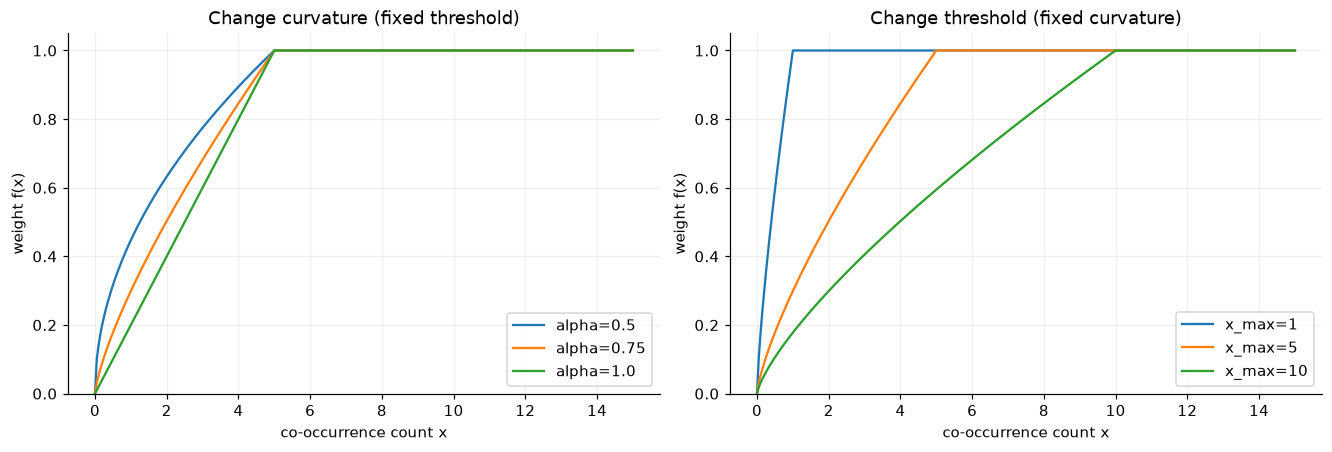

,x,"f(x), x_max=5","f(x), x_max=100"
0,0,0.0000,0.0000
1,1,0.2991,0.0316
2,2,0.5030,0.0532
3,5,1.0000,0.1057
4,10,1.0000,0.1778
5,100,1.0000,1.0000


In [10]:
count_grid = np.linspace(0, 15, 301)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
for alpha in CONFIG.alpha_grid:
    axes[0].plot(count_grid, weighting(count_grid, CONFIG.x_max, alpha), label=f"alpha={alpha}")
for threshold in CONFIG.x_max_grid:
    axes[1].plot(count_grid, weighting(count_grid, threshold, CONFIG.alpha), label=f"x_max={threshold:g}")
for ax in axes:
    ax.set(xlabel="co-occurrence count x", ylabel="weight f(x)", ylim=(0, 1.05))
    ax.legend()
    ax.grid(alpha=0.2)
axes[0].set_title("Change curvature (fixed threshold)")
axes[1].set_title("Change threshold (fixed curvature)")
plt.show()
display(pd.DataFrame({"x": [0, 1, 2, 5, 10, 100],
    "f(x), x_max=5": weighting([0, 1, 2, 5, 10, 100], 5, 0.75),
    "f(x), x_max=100": weighting([0, 1, 2, 5, 10, 100], 100, 0.75)}))

**Knowledge check — pause here.** If f(0)=0, can we safely evaluate 0 times log(0) in code?

**Answer**

No. log(0) is not finite and zero times infinity is undefined numerically. Select X_ij > 0 before computing logs. Do not replace missing counts with log(1)=0 targets.

## 9. Implement GloVe From Scratch

We store four independent parameter arrays: $W,\widetilde W\in\mathbb R^{V\times d}$
and $b,\tilde b\in\mathbb R^V$. All start from small random numbers from a seeded
CPU generator. There is no GloVe library, neural network wrapper, or hidden objective.

For $N$ observed ordered pairs we optimize $\bar J=J/N$: its minimizers are the same
as the sum because $N$ is fixed within a run. We record both. One epoch is one
full-batch Adam update over the observed pairs. This is convenient for a tiny matrix;
the original implementation uses a different optimizer and training strategy.

To see what autodiff computes, the single-pair gradients are

$$\frac{\partial\ell_{ij}}{\partial w_i}=2f(X_{ij})e_{ij}\tilde w_j,
\quad\frac{\partial\ell_{ij}}{\partial\tilde w_j}=2f(X_{ij})e_{ij}w_i,
\quad\frac{\partial\ell_{ij}}{\partial b_i}
=\frac{\partial\ell_{ij}}{\partial\tilde b_j}=2f(X_{ij})e_{ij}.$$

$\ell_{ij}=f(X_{ij})e_{ij}^2$ is one loss term; the count and weight are fixed data.
For our earlier example, the shared scalar multiplier is about $-0.023285$,
so the target-vector gradient is approximately $[-0.011643,-0.006986]$.
Gradients from every pair involving a parameter add together (and divide by $N$
for the mean). SGD would subtract learning rate times the gradient; Adam adapts
that step using moving gradient moments. PyTorch supplies only autodiff and Adam.

shared scalar                                                       -0.0233
d loss / d target vector     [-0.011642415455592848, -0.006985449273355708]
d loss / d context vector       [-0.00465696618223714, 0.00232848309111857]
d loss / d either bias                                              -0.0233
dtype: object

,epoch,J_sum,J_mean
0,0,97.2258,5.2272e-01
1,1,88.2024,4.7421e-01
10,10,31.2919,1.6824e-01
100,100,0.3754,2.0181e-03
1000,1000,0.0126,6.7999e-05


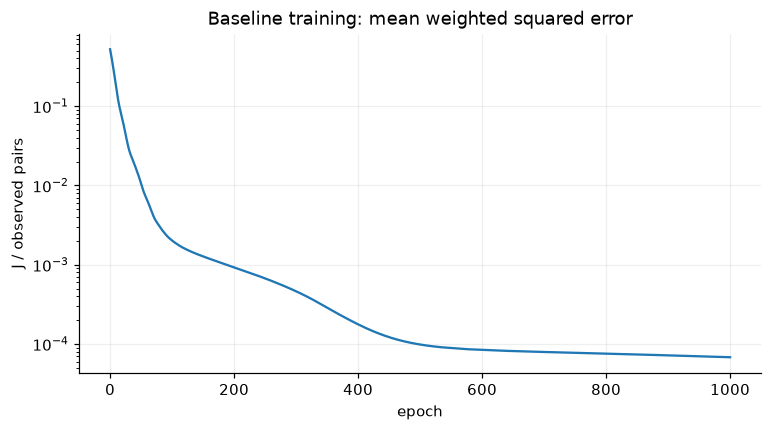

**Observed convergence:** mean loss changed from 0.522720 to 0.000068 in 0.29 seconds. The history includes every epoch; the table samples a few. Falling reconstruction error measures fit to counts, not semantic accuracy. Adam's steps need not decrease the loss at every epoch.

In [11]:
gradient_multiplier = 2 * weighting(pair_x) * pair_error
display(pd.Series({"shared scalar": float(gradient_multiplier),
                   "d loss / d target vector": gradient_multiplier * pair_context,
                   "d loss / d context vector": gradient_multiplier * pair_w,
                   "d loss / d either bias": float(gradient_multiplier)}))

def train_glove(X, dimension=2, learning_rate=0.03, epochs=1000,
                x_max=5.0, alpha=0.75, seed=7):
    """Fit explicit CPU parameters; return NumPy arrays and post-update epoch losses."""
    if not isinstance(dimension, int) or dimension < 1 or not isinstance(epochs, int) or epochs < 1:
        raise ValueError("dimension and epochs must be positive integers")
    if not np.isfinite(learning_rate) or learning_rate <= 0:
        raise ValueError("learning_rate must be finite and positive")
    target_ids, context_ids, counts = observed_pairs(X)
    i = torch.tensor(target_ids, dtype=torch.long)
    j = torch.tensor(context_ids, dtype=torch.long)
    log_targets = torch.tensor(np.log(counts), dtype=DTYPE)
    weights = torch.tensor(weighting(counts, x_max, alpha), dtype=DTYPE)
    generator = torch.Generator(device="cpu").manual_seed(seed)
    V = X.shape[0]
    W = torch.nn.Parameter(0.1 * torch.randn((V, dimension), generator=generator, dtype=DTYPE))
    W_context = torch.nn.Parameter(0.1 * torch.randn((V, dimension), generator=generator, dtype=DTYPE))
    b = torch.nn.Parameter(0.01 * torch.randn(V, generator=generator, dtype=DTYPE))
    b_context = torch.nn.Parameter(0.01 * torch.randn(V, generator=generator, dtype=DTYPE))
    optimizer = torch.optim.Adam([W, W_context, b, b_context], lr=learning_rate)

    def pair_losses():
        dot_products = (W[i] * W_context[j]).sum(dim=1)
        predictions = dot_products + b[i] + b_context[j]
        errors = predictions - log_targets
        return weights * errors.square()

    with torch.no_grad():
        history = [{"epoch": 0, "J_sum": pair_losses().sum().item(),
                    "J_mean": pair_losses().mean().item()}]
    started = perf_counter()
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()
        loss = pair_losses().mean()
        if not torch.isfinite(loss):
            raise FloatingPointError("Non-finite loss: inspect counts and learning rate")
        loss.backward()
        optimizer.step()
        with torch.no_grad():
            losses = pair_losses()
            if not torch.isfinite(losses).all():
                raise FloatingPointError("Non-finite post-update loss")
            history.append({"epoch": epoch, "J_sum": losses.sum().item(),
                            "J_mean": losses.mean().item()})
    return {"W": W.detach().numpy().copy(), "W_context": W_context.detach().numpy().copy(),
            "b": b.detach().numpy().copy(), "b_context": b_context.detach().numpy().copy(),
            "history": pd.DataFrame(history), "seconds": perf_counter() - started,
            "seed": seed, "observed_pairs": len(counts)}

# Cache identical training runs, including the corpus, to reuse sweep baselines.
RUN_CACHE = {}

def get_run(config, seed=None):
    """Build statistics and train once for each distinct data/hyperparameter/seed tuple."""
    seed = config.seeds[0] if seed is None else seed
    key = (tuple(config.corpus), config.max_vocab, config.window, config.dimension,
           config.learning_rate, config.epochs, config.alpha, config.x_max,
           config.distance_weighting, seed)
    if key not in RUN_CACHE:
        tokens = [tokenize(s) for s in config.corpus]
        words, ids, _ = build_vocabulary(tokens, config.max_vocab)
        counts = build_cooccurrence(tokens, ids, config.window, config.distance_weighting)
        model = train_glove(counts, config.dimension, config.learning_rate, config.epochs,
                            config.x_max, config.alpha, seed)
        model.update({"X": counts, "vocab": words, "word_to_id": ids, "config": config,
                      "vectors": model["W"] + model["W_context"]})
        RUN_CACHE[key] = model
    return RUN_CACHE[key]

baseline = get_run(CONFIG)
history = baseline["history"]
display(history.iloc[sorted(set([0, 1, 10, 100, len(history) - 1]) & set(range(len(history))))])
ax = history.plot(x="epoch", y="J_mean", legend=False, figsize=(8, 4), logy=True)
ax.set(title="Baseline training: mean weighted squared error", ylabel="J / observed pairs")
ax.grid(alpha=0.2)
plt.show()
display(Markdown(f"**Observed convergence:** mean loss changed from "
    f"{history.J_mean.iloc[0]:.6f} to {history.J_mean.iloc[-1]:.6f} "
    f"in {baseline['seconds']:.2f} seconds. The history includes every epoch; "
    "the table samples a few. Falling reconstruction error measures fit to counts, "
    "not semantic accuracy. Adam's steps need not decrease the loss at every epoch."))

## 10. Inspect the Learned Parameters

One word can play two roles: the target whose surroundings we summarize, or a context
feature of another target. Separate parameters model those roles. Symmetric counts
make the objective invariant to swapping the two complete parameter sets, but do not
force corresponding vectors or biases to be equal.

A common final representation adds the roles:

$$E_i=w_i+\tilde w_i.$$

$E_i\in\mathbb R^d$ is the final vector for word $i$. If $w_i=[0.2,-0.1]$ and
$\tilde w_i=[0.4,0.3]$, then $E_i=[0.6,0.2]$. Averaging instead gives the same
cosine rankings because it rescales every vector by the same positive constant.
Summing often helps by using both learned views; it is a convention, not a theorem
guaranteeing improved neighbors. The reconstruction objective uses the **separate** matrices.

In [12]:
W, W_context = baseline["W"], baseline["W_context"]
b, b_context = baseline["b"], baseline["b_context"]
E = W + W_context
columns = [f"coordinate {i + 1}" for i in range(E.shape[1])]
for label, values in [("Target W", W), ("Context W_tilde", W_context), ("Final E = W + W_tilde", E)]:
    display(Markdown(f"**{label}**"))
    display(pd.DataFrame(values, index=vocab, columns=columns))
display(pd.DataFrame({"target bias": b, "context bias": b_context,
                      "token frequency": [frequencies[w] for w in vocab]}, index=vocab))
print("Addition example:", np.array([0.2, -0.1]) + np.array([0.4, 0.3]))
print("Frobenius norm of W - W_tilde:", np.linalg.norm(W - W_context))

**Target W**

,coordinate 1,coordinate 2
a,1.6287,-0.4960
berlin,-0.2072,0.5179
capital,0.2381,0.4471
cat,-0.1454,1.5165
cold,-0.3039,0.4459
crown,0.2867,-0.4181
dog,-0.1454,1.5165
france,-0.4789,1.6218
gas,0.9611,1.2526
germany,-0.4404,1.6397


**Context W_tilde**

,coordinate 1,coordinate 2
a,2.0521,0.0426
berlin,-0.8370,-0.9375
capital,-0.1394,-0.8470
cat,-0.6975,-1.6251
cold,-0.5374,0.2305
crown,0.4595,0.5546
dog,-0.6975,-1.6251
france,0.2525,0.4422
gas,-0.5185,-0.3202
germany,0.5339,0.6073


**Final E = W + W_tilde**

,coordinate 1,coordinate 2
a,3.6808,-0.4534
berlin,-1.0441,-0.4195
capital,0.0987,-0.3999
cat,-0.8428,-0.1086
cold,-0.8413,0.6764
crown,0.7462,0.1365
dog,-0.8429,-0.1086
france,-0.2264,2.0640
gas,0.4426,0.9324
germany,0.0934,2.2470


,target bias,context bias,token frequency
a,0.2910,0.1909,12
berlin,0.2137,0.6049,3
capital,-0.0054,0.2091,2
cat,0.0397,0.0347,4
cold,-0.4731,-0.5787,1
crown,0.6249,0.6219,4
dog,0.0397,0.0347,4
france,0.2325,-1.0546,1
gas,0.1235,0.2601,2
germany,0.2260,-1.2495,1


Addition example: [0.6 0.2]
Frobenius norm of W - W_tilde: 10.363261456290239


**Knowledge check — pause here.** Must target and context vectors match when X is symmetric?

**Answer**

No. The objective permits swapped solutions and many equivalent parameterizations. Independent initialization and joint optimization need not make the two arrays identical.

## 11. Visualize the Embedding Space

Train directly in two dimensions: these are learned coordinates, not a PCA or t-SNE
projection. Each point below is a row of $E$. Labels are displaced vertically when
needed for readability, with leader lines locating the actual vectors. Colors mark
our chosen word groups; they are annotations, never training labels.

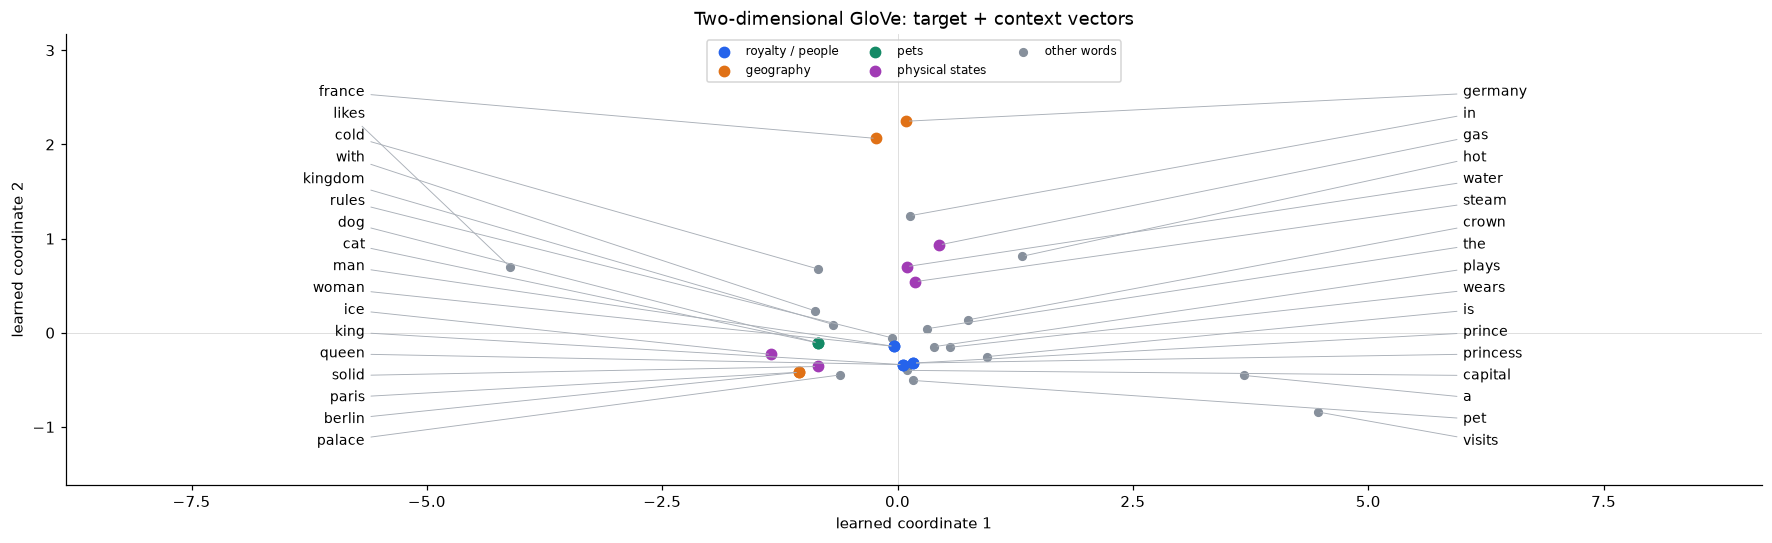

In [13]:
WORD_GROUPS = {
    "royalty / people": {"king", "queen", "man", "woman", "prince", "princess"},
    "geography": {"france", "paris", "germany", "berlin"},
    "pets": {"dog", "cat"},
    "physical states": {"ice", "steam", "solid", "gas", "water"},
}

def plot_embeddings_2d(run, title):
    """Plot all actual 2D vectors, using separate side columns to avoid label overlap."""
    vectors, words = run["vectors"], run["vocab"]
    if vectors.shape[1] != 2:
        raise ValueError("This plot requires a model trained with dimension=2")
    fig, ax = plt.subplots(figsize=(16, 7), layout="constrained")
    palette = ["#2563eb", "#e07116", "#148a66", "#a13bb5"]
    assigned = set()
    for (name, group), color in zip(WORD_GROUPS.items(), palette):
        ids = [i for i, w in enumerate(words) if w in group]
        assigned.update(ids)
        ax.scatter(vectors[ids, 0], vectors[ids, 1], label=name, color=color, s=45, zorder=3)
    rest = [i for i in range(len(words)) if i not in assigned]
    ax.scatter(vectors[rest, 0], vectors[rest, 1], label="other words", color="#87909c", s=25)
    xmin, ymin = vectors.min(axis=0)
    xmax, ymax = vectors.max(axis=0)
    width, height = max(xmax - xmin, 1.0), max(ymax - ymin, 1.0)
    middle = np.median(vectors[:, 0])
    for left in (True, False):
        ids = [i for i in range(len(words)) if (vectors[i, 0] <= middle) == left]
        ids.sort(key=lambda i: vectors[i, 1])
        label_ys = np.linspace(ymin - 0.1 * height, ymax + 0.1 * height, len(ids))
        label_x = xmin - 0.18 * width if left else xmax + 0.18 * width
        for i, label_y in zip(ids, label_ys):
            ax.annotate(words[i], xy=vectors[i], xytext=(label_x, label_y),
                        ha="right" if left else "left", va="center", fontsize=9,
                        arrowprops={"arrowstyle": "-", "color": "#aab0b8", "lw": 0.6})
    ax.set(xlim=(xmin - 0.55 * width, xmax + 0.55 * width),
           ylim=(ymin - 0.25 * height, ymax + 0.30 * height),
           xlabel="learned coordinate 1", ylabel="learned coordinate 2", title=title)
    ax.axhline(0, color="#dddddd", lw=0.6)
    ax.axvline(0, color="#dddddd", lw=0.6)
    ax.set_aspect("equal", adjustable="box")  # One unit has the same visual length on both axes.
    ax.legend(loc="upper center", ncol=3, fontsize=8)
    plt.show()

run_2d = get_run(replace(CONFIG, dimension=2))
plot_embeddings_2d(run_2d, "Two-dimensional GloVe: target + context vectors")

**How to read this plot.** Inspect king/queen, man/woman, prince/princess,
France/Paris, Germany/Berlin, and dog/cat. Shared sentence templates may produce
similar contexts, but co-occurrence is not identical to similarity. A country and
its capital may occur together without becoming nearest neighbors.
Point proximity is Euclidean; the next section compares directions with cosine.
We will quantify which pairs actually align instead of interpreting colors as a result.

Coordinate signs and orientations have no intrinsic semantic meaning. More generally,
replacing $W$ by $WA$ and $\widetilde W$ by $\widetilde W A^{-T}$ for an invertible
$d\times d$ matrix $A$ preserves all cross dot products. For example, $A=2I$ doubles
target vectors and halves context vectors with no change in fit. This freedom need
not preserve cosines of their sums. Therefore a good reconstruction alone does not
uniquely specify a useful embedding geometry; initialization and optimization matter.

In [14]:
print("Maximum cross-dot change after W*=2, W_tilde/=2:",
      np.max(np.abs((2 * W) @ (W_context / 2).T - W @ W_context.T)))

Maximum cross-dot change after W*=2, W_tilde/=2: 0.0


## 12. Cosine Similarity

Cosine compares direction while ignoring positive scale:

$$\cos(u,v)=\frac{u^Tv}{\|u\|_2\|v\|_2}.$$

$u,v$ are nonzero word vectors and $\|\cdot\|_2$ is Euclidean length.
For $u=[1,0]$ and $v=[1,1]$, the numerator is 1, lengths are 1 and $\sqrt2$,
and cosine is $1/\sqrt2\approx0.7071$. Multiplying $v$ by 10 changes its distance
from $u$ but not their cosine. This often helps when vector norms reflect frequency
or training scale. It is not universally superior: norm may carry useful information.
On unit-normalized vectors, squared Euclidean distance equals $2-2\cos(u,v)$.

We return NaN for zero-vector cosine, exclude undefined candidates, and report an
absent query explicitly. Nearest-neighbor tables never include the query itself.

In [15]:
def cosine_similarity(u, v):
    """Cosine from dot products and lengths; a zero vector has undefined cosine."""
    u, v = np.asarray(u, dtype=float), np.asarray(v, dtype=float)
    denominator = np.linalg.norm(u) * np.linalg.norm(v)
    return float(np.clip(np.dot(u, v) / denominator, -1, 1)) if denominator > 0 else np.nan

def rank_vectors(query, vectors, words, exclude=()):
    """Score every word, excluding requested words and undefined zero-norm scores."""
    table = pd.DataFrame({"word": words,
                          "cosine": [cosine_similarity(query, row) for row in vectors]})
    table = table[~table.word.isin(exclude)].dropna(subset=["cosine"])
    table = table.sort_values(["cosine", "word"], ascending=[False, True]).reset_index(drop=True)
    table.insert(0, "rank", np.arange(1, len(table) + 1))
    return table

def nearest(word, run=baseline, top_k=5):
    """Retrieve neighbors for an in-vocabulary query, omitting the query itself."""
    if word not in run["word_to_id"]:
        raise KeyError(f"{word!r} is not in this model's vocabulary")
    vector = run["vectors"][run["word_to_id"][word]]
    return rank_vectors(vector, run["vectors"], run["vocab"], exclude={word}).head(top_k)

print("cos([1,0], [1,1]) =", cosine_similarity([1, 0], [1, 1]))
print("cos([1,0], [10,10]) =", cosine_similarity([1, 0], [10, 10]))
u, v = np.array([1., 0.]), np.array([1., 1.]) / np.sqrt(2)
print("Unit-vector squared distance:", np.sum((u - v) ** 2),
      "; 2 - 2 cosine:", 2 - 2 * cosine_similarity(u, v))
neighbor_tables = []
for query in ("king", "queen", "paris", "dog"):
    if query in word_to_id:
        neighbor_tables.append(nearest(query).assign(query=query))
if neighbor_tables:
    display(pd.concat(neighbor_tables)[["query", "rank", "word", "cosine"]])

SEMANTIC_PAIRS = [("king", "queen"), ("man", "woman"), ("prince", "princess"),
                  ("france", "paris"), ("germany", "berlin"), ("dog", "cat")]
pair_scores = pd.DataFrame([
    {"pair": f"{a} / {c}", "cosine": cosine_similarity(E[word_to_id[a]], E[word_to_id[c]])}
    for a, c in SEMANTIC_PAIRS if a in word_to_id and c in word_to_id])
display(pair_scores)
if not pair_scores.empty:
    ordered = pair_scores.sort_values("cosine", ascending=False)
    display(Markdown(f"**Observed pattern:** among these selected pairs, "
        f"**{ordered.iloc[0]['pair']}** has the highest cosine ({ordered.iloc[0]['cosine']:.3f}), "
        f"and **{ordered.iloc[-1]['pair']}** the lowest ({ordered.iloc[-1]['cosine']:.3f}). "
        "These scores describe this run; they do not establish general semantic quality. "
        "In two dimensions, many unrelated words can share almost the same direction."))

cos([1,0], [1,1]) = 0.7071067811865475
cos([1,0], [10,10]) = 0.7071067811865475
Unit-vector squared distance: 0.5857864376269049 ; 2 - 2 cosine: 0.5857864376269049


,query,rank,word,cosine
0,king,1,queen,1.0000
1,king,2,capital,0.9973
2,king,3,pet,0.9885
3,king,4,prince,0.9523
4,king,5,princess,0.9523
0,queen,1,king,1.0000
1,queen,2,capital,0.9973
2,queen,3,pet,0.9884
3,queen,4,prince,0.9523
4,queen,5,princess,0.9523


,pair,cosine
0,king / queen,1.0000
1,man / woman,1.0000
2,prince / princess,1.0000
3,france / paris,-0.2694
4,germany / berlin,-0.4111
5,dog / cat,1.0000


**Observed pattern:** among these selected pairs, **dog / cat** has the highest cosine (1.000), and **germany / berlin** the lowest (-0.411). These scores describe this run; they do not establish general semantic quality. In two dimensions, many unrelated words can share almost the same direction.

## 13. Vector Analogies

An analogy query adds an observed offset to a starting vector:

$$q=E_a-E_b+E_c,\qquad
\widehat d=\arg\max_{v\notin\{a,b,c\}}\cos(q,E_v).$$

$a,b,c$ are query words, $q$ is the resulting vector, and $\widehat d$ is the highest
scoring eligible vocabulary word. For a purely arithmetic illustration,
$[2,1]-[1,0]+[1,1]=[2,2]$. Actual model vectors are used below, without adjustment.
We score all eligible words and show the top five plus the expected answer's rank.

In [16]:
ANALOGIES = [("king", "man", "woman", "queen"),
             ("paris", "france", "germany", "berlin"),
             ("prince", "man", "woman", "princess")]

def analogy(a, b, c, run=baseline):
    """Rank q=E_a-E_b+E_c; query words cannot win by copying an input."""
    missing = sorted({a, b, c} - set(run["word_to_id"]))
    if missing:
        raise KeyError(f"Missing analogy inputs: {missing}")
    ids, vectors = run["word_to_id"], run["vectors"]
    query = vectors[ids[a]] - vectors[ids[b]] + vectors[ids[c]]
    return query, rank_vectors(query, vectors, run["vocab"], exclude={a, b, c})

def analogy_summary(run):
    """Descriptive ranks for the three teaching prompts, not a benchmark score."""
    rows = []
    for a, b, c, expected in ANALOGIES:
        label = f"{a} - {b} + {c}"
        if not {a, b, c, expected}.issubset(run["word_to_id"]):
            rows.append({"query": label, "expected": expected, "top word": None,
                         "expected rank": np.nan, "status": "missing vocabulary"})
            continue
        _, ranking = analogy(a, b, c, run)
        answer = ranking.loc[ranking.word == expected]
        rows.append({"query": label, "expected": expected,
                     "top word": ranking.word.iloc[0] if len(ranking) else None,
                     "expected rank": int(answer['rank'].iloc[0]) if len(answer) else np.nan,
                     "status": "ranked" if len(answer) else "undefined cosine"})
    return pd.DataFrame(rows)

print("Arithmetic example:", np.array([2, 1]) - np.array([1, 0]) + np.array([1, 1]))
for a, b_word, c, expected in ANALOGIES:
    if {a, b_word, c}.issubset(word_to_id):
        query, ranking = analogy(a, b_word, c)
        display(Markdown(f"**{a} − {b_word} + {c}**, expected: **{expected}**; query = `{query}`"))
        display(ranking.head(5))
baseline_analogies = analogy_summary(baseline)
display(baseline_analogies)
for row in baseline_analogies.to_dict("records"):
    display(Markdown(f"**{row['query']}:** top result **{row['top word']}**; "
        f"expected **{row['expected']}** has rank **{row['expected rank']}** ({row['status']})."))

Arithmetic example: [2 2]


**king − man + woman**, expected: **queen**; query = `[ 0.0578485  -0.33896245]`

,rank,word,cosine
0,1,queen,1.0000
1,2,capital,0.9973
2,3,pet,0.9884
3,4,prince,0.9523
4,5,princess,0.9523


**paris − france + germany**, expected: **berlin**; query = `[-0.724271   -0.23651263]`

,rank,word,cosine
0,1,berlin,0.9978
1,2,solid,0.9965
2,3,ice,0.9895
3,4,cat,0.9825
4,5,dog,0.9825


...

,rank,word,cosine
0,1,princess,1.0000
1,2,pet,0.9876
2,3,capital,0.9721
3,4,king,0.9523
4,5,queen,0.9523


,query,expected,top word,expected rank,status
0,king - man + woman,queen,queen,1,ranked
1,paris - france + germany,berlin,berlin,1,ranked
2,prince - man + woman,princess,princess,1,ranked


**king - man + woman:** top result **queen**; expected **queen** has rank **1** (ranked).

**paris - france + germany:** top result **berlin**; expected **berlin** has rank **1** (ranked).

**prince - man + woman:** top result **princess**; expected **princess** has rank **1** (ranked).

**Interpretation.** These prompts are probes, not constraints in the loss. Matching
observed log counts does not directly train the equality king − man + woman = queen.
Few occurrences, asymmetric templates, two-dimensional capacity, and optimizer
choices can all affect rankings. Even a successful prompt would not prove a general
gender or geography direction. All three prompts and all fixed seeds remain in the
results regardless of whether they work.

## 14. Effect of Embedding Dimension

Now repeat each dimension with the same three seed values. Each comparison changes
only one configuration field; the corpus and all other settings stay fixed. Equal
seed numbers across different shapes do not imply identical initial coordinates.

The model has $2Vd+2V$ scalar parameters: two $V\times d$ matrices and two length-$V$
bias arrays. For $V=40,d=2$, that is $160+80=240$. More dimensions allow more ways to
fit the observed cells, but offer no guarantee of better meanings from limited data.
There is no held-out semantic dataset here, so “quality” is assessed descriptively
through neighbors and analogy ranks, not a claimed generalization score.

The reusable sweep code records final loss, weighted reconstruction RMSE, late-epoch
loss variation, seed variation in neighbor sets, and the three analogy probes.

Weighted RMSE is $\sqrt{J/\sum_{X_{ij}>0}f(X_{ij})}$: take the square root of the
weighted mean squared residual. It has log-count units. For residuals 1 and 2 with
weights 1 and 0.5, $J=1\times1^2+0.5\times2^2=3$, total weight is 1.5,
and weighted RMSE is $\sqrt{3/1.5}=\sqrt2\approx1.4142$.

,mean_final_loss,std_final_loss,mean_weighted_RMSE,mean_late_loss_range,observed_pairs,parameters
dimension,,,,,,
2,6.0513e-05,1.7145e-05,0.0111,4.8082e-06,186,204
5,1.7619e-08,6.2284e-09,0.0002,6.1459e-07,186,408
10,1.4457e-07,9.2612e-08,0.0005,7.4019e-07,186,748
20,2.8214e-07,2.1722e-07,0.0007,1.2159e-06,186,1428


,dimension,seed,initial J_mean,final J_sum,final J_mean,weighted RMSE,late loss range,upward steps,seconds,observed pairs,parameters
0,2,7,0.5227,1.2648e-02,6.7999e-05,0.0118,3.7403e-06,8,0.2891,186,204
1,2,17,0.5242,7.6072e-03,4.0899e-05,0.0092,2.2895e-06,23,0.2684,186,204
2,2,27,0.5228,1.3512e-02,7.2643e-05,0.0122,8.3948e-06,0,0.2707,186,204
3,5,7,0.5287,3.0255e-06,1.6266e-08,0.0002,4.9850e-07,460,0.2534,186,408
4,5,17,0.5224,4.5408e-06,2.4413e-08,0.0002,6.4829e-07,283,0.2623,186,408
5,5,27,0.5252,2.2652e-06,1.2179e-08,0.0002,6.9700e-07,343,0.2531,186,408
6,10,7,0.5207,9.7657e-06,5.2504e-08,0.0003,1.1751e-06,408,0.2632,186,748
7,10,17,0.5249,4.4216e-05,2.3772e-07,0.0007,5.4104e-07,490,0.2558,186,748
8,10,27,0.5181,2.6690e-05,1.4349e-07,0.0005,5.0446e-07,454,0.2610,186,748
9,20,7,0.5343,9.8515e-05,5.2965e-07,0.0010,1.1998e-06,523,0.2808,186,1428


,dimension,seed,query,top 3
0,2,7,king,"queen, capital, pet"
1,2,7,queen,"king, capital, pet"
2,2,7,paris,"berlin, solid, ice"
3,2,7,dog,"cat, ice, paris"
4,2,17,king,"queen, woman, man"
5,2,17,queen,"king, woman, man"
6,2,17,paris,"pet, berlin, a"
7,2,17,dog,"cat, visits, the"
8,2,27,king,"queen, prince, princess"
9,2,27,queen,"king, prince, princess"


,query,expected,top word,expected rank,status,dimension,seed
0,king - man + woman,queen,queen,1,ranked,2,7
1,paris - france + germany,berlin,berlin,1,ranked,2,7
2,prince - man + woman,princess,princess,1,ranked,2,7
3,king - man + woman,queen,queen,1,ranked,2,17
4,paris - france + germany,berlin,palace,7,ranked,2,17
5,prince - man + woman,princess,princess,1,ranked,2,17
6,king - man + woman,queen,queen,1,ranked,2,27
7,paris - france + germany,berlin,berlin,1,ranked,2,27
8,prince - man + woman,princess,princess,1,ranked,2,27
9,king - man + woman,queen,queen,1,ranked,5,7


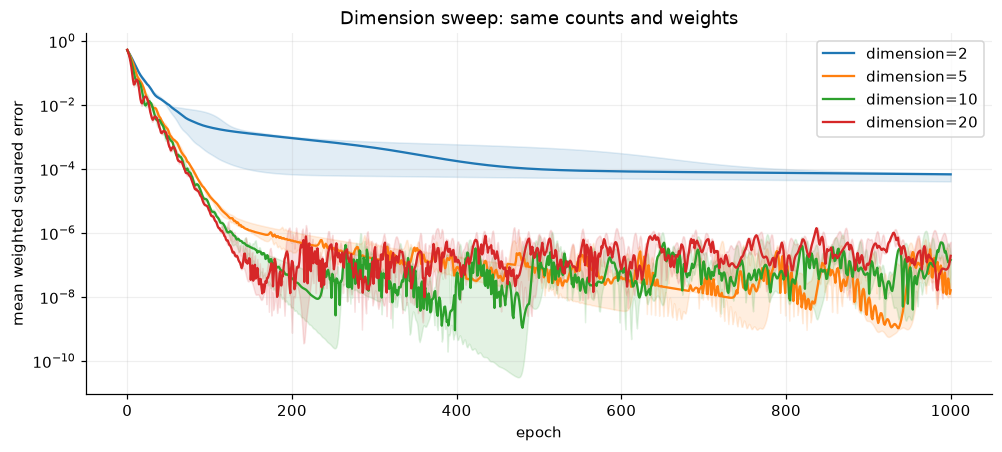

**Observed results.** `dimension=2`: mean final loss 6.051e-05 (seed SD 1.714e-05); `dimension=5`: mean final loss 1.762e-08 (seed SD 6.228e-09); `dimension=10`: mean final loss 1.446e-07 (seed SD 9.261e-08); `dimension=20`: mean final loss 2.821e-07 (seed SD 2.172e-07). Curves show the median and the full seed range, not confidence intervals.

Parameter-count example, V=40, d=2: 240
Weighted RMSE example: 1.4142135623730951


In [17]:
def run_metrics(run):
    """Measure fit and descriptive optimization behavior, without a semantic claim."""
    cfg, h = run["config"], run["history"]
    _, _, counts = observed_pairs(run["X"])
    weight_sum = weighting(counts, cfg.x_max, cfg.alpha).sum()
    tail = h.J_mean.tail(min(100, len(h)))
    return {"seed": run["seed"], "initial J_mean": h.J_mean.iloc[0],
            "final J_sum": h.J_sum.iloc[-1], "final J_mean": h.J_mean.iloc[-1],
            "weighted RMSE": np.sqrt(h.J_sum.iloc[-1] / weight_sum),
            "late loss range": tail.max() - tail.min(),
            "upward steps": int((np.diff(h.J_mean) > 1e-12).sum()),
            "seconds": run["seconds"], "observed pairs": run["observed_pairs"],
            "parameters": 2 * len(run["vocab"]) * (cfg.dimension + 1)}

def sweep(field, values, config=CONFIG):
    """One-factor-at-a-time sweep; identical baselines are retrieved from RUN_CACHE."""
    runs, metrics, neighbors, analogy_rows = [], [], [], []
    for value in values:
        for seed in config.seeds:
            run = get_run(replace(config, **{field: value}), seed)
            runs.append((value, run))
            metrics.append({field: value, **run_metrics(run)})
            for query in ("king", "queen", "paris", "dog"):
                if query in run["word_to_id"]:
                    top = nearest(query, run, top_k=3)
                    neighbors.append({field: value, "seed": seed, "query": query,
                                      "top 3": ", ".join(top.word)})
            analogy_rows.append(analogy_summary(run).assign(**{field: value, "seed": seed}))
    return {"field": field, "runs": runs, "metrics": pd.DataFrame(metrics),
            "neighbors": pd.DataFrame(neighbors), "analogies": pd.concat(analogy_rows, ignore_index=True)}

def show_sweep(result, title):
    """Show all seeds, aggregate fits, and convergence curves for a controlled sweep."""
    field, metrics = result["field"], result["metrics"]
    grouped = metrics.groupby(field, sort=False).agg(
        mean_final_loss=("final J_mean", "mean"), std_final_loss=("final J_mean", "std"),
        mean_weighted_RMSE=("weighted RMSE", "mean"),
        mean_late_loss_range=("late loss range", "mean"),
        observed_pairs=("observed pairs", "first"), parameters=("parameters", "first"))
    display(grouped)
    display(metrics)
    if not result["neighbors"].empty:
        display(result["neighbors"])
    display(result["analogies"])
    fig, ax = plt.subplots(figsize=(9, 4), layout="constrained")
    values = metrics[field].drop_duplicates().tolist()
    for value in values:
        histories = [run["history"].J_mean.to_numpy() for val, run in result["runs"] if val == value]
        histories = np.stack(histories)
        epochs = np.arange(histories.shape[1])
        line, = ax.plot(epochs, np.median(histories, axis=0), label=f"{field}={value}")
        ax.fill_between(epochs, histories.min(axis=0), histories.max(axis=0),
                        alpha=0.13, color=line.get_color())
    ax.set(xlabel="epoch", ylabel="mean weighted squared error", title=title, yscale="log")
    ax.legend()
    ax.grid(alpha=0.2)
    plt.show()
    statements = [f"`{field}={value}`: mean final loss {row.mean_final_loss:.3e} "
                  f"(seed SD {row.std_final_loss:.3e})" for value, row in grouped.iterrows()]
    display(Markdown("**Observed results.** " + "; ".join(statements) +
                    ". Curves show the median and the full seed range, not confidence intervals."))
    return grouped

dimension_results = sweep("dimension", CONFIG.dimension_grid)
dimension_summary = show_sweep(dimension_results, "Dimension sweep: same counts and weights")
print("Parameter-count example, V=40, d=2:", 2 * 40 * 2 + 2 * 40)
print("Weighted RMSE example:", np.sqrt((1 * 1**2 + 0.5 * 2**2) / (1 + 0.5)))

**Interpretation.** Losses in this dimension sweep share the same targets and weights,
so reconstruction fit is directly comparable. The larger model families can express
the smaller ones, but a finite optimizer run may not find the best fit.
Inspect whether lower losses actually move the expected answers up the analogy tables.
Near-zero training error may reflect spare capacity rather than rich semantics.
Seed variation and late loss variation describe training sensitivity; neither is a
statistical estimate of performance on natural language.

## 15. Effect of Context Window Size

Radius 1 sees immediate neighbors; radii 2 and 4 include more surrounding positions.
Smaller windows often emphasize substitutable grammatical roles, while larger windows
can capture broader topics. This is a tendency, not a law that 30 short sentences can
establish. Aggregated symmetric windows also discard the original left/right order.

Keep dimension and all optimization settings fixed. Compare the count density,
neighbor tables, and seed variability. The raw coordinates of independently trained
models are not aligned, so we compare within-model rankings rather than subtracting
their coordinates.

,mean_final_loss,std_final_loss,mean_weighted_RMSE,mean_late_loss_range,observed_pairs,parameters
window,,,,,,
1,6.4702e-08,5.5615e-08,0.0003,6.5270e-07,120,204
2,6.0513e-05,1.7145e-05,0.0111,4.8082e-06,186,204
4,3.6497e-03,2.5180e-05,0.0882,4.7337e-05,249,204


,window,seed,initial J_mean,final J_sum,final J_mean,weighted RMSE,late loss range,upward steps,seconds,observed pairs,parameters
0,1,7,0.3782,1.2279e-05,1.0233e-07,4.7453e-04,2.6257e-07,246,0.2451,120,204
1,1,17,0.3835,1.0915e-05,9.0958e-08,4.4739e-04,1.5422e-06,155,0.2444,120,204
2,1,27,0.3812,9.8415e-08,8.2012e-10,4.2482e-05,1.5328e-07,261,0.2441,120,204
3,2,7,0.5227,1.2648e-02,6.7999e-05,1.1847e-02,3.7403e-06,8,0.2891,186,204
4,2,17,0.5242,7.6072e-03,4.0899e-05,9.1880e-03,2.2895e-06,23,0.2684,186,204
5,2,27,0.5228,1.3512e-02,7.2643e-05,1.2245e-02,8.3948e-06,0,0.2707,186,204
6,4,7,0.5803,9.1091e-01,3.6583e-03,8.8288e-02,4.4609e-05,8,0.2581,249,204
7,4,17,0.5815,9.0171e-01,3.6213e-03,8.7840e-02,3.9955e-05,12,0.2586,249,204
8,4,27,0.5802,9.1368e-01,3.6694e-03,8.8422e-02,5.7446e-05,0,0.2617,249,204


,window,seed,query,top 3
0,1,7,king,"queen, capital, prince"
1,1,7,queen,"king, capital, prince"
2,1,7,paris,"pet, berlin, crown"
3,1,7,dog,"cat, man, woman"
4,1,17,king,"queen, hot, cat"
5,1,17,queen,"king, hot, cat"
6,1,17,paris,"berlin, wears, a"
7,1,17,dog,"cat, king, queen"
8,1,27,king,"queen, dog, cat"
9,1,27,queen,"king, dog, cat"


,query,expected,top word,expected rank,status,window,seed
0,king - man + woman,queen,queen,1,ranked,1,7
1,paris - france + germany,berlin,berlin,1,ranked,1,7
2,prince - man + woman,princess,princess,1,ranked,1,7
3,king - man + woman,queen,queen,1,ranked,1,17
4,paris - france + germany,berlin,berlin,1,ranked,1,17
5,prince - man + woman,princess,princess,1,ranked,1,17
6,king - man + woman,queen,queen,1,ranked,1,27
7,paris - france + germany,berlin,crown,4,ranked,1,27
8,prince - man + woman,princess,princess,1,ranked,1,27
9,king - man + woman,queen,queen,1,ranked,2,7


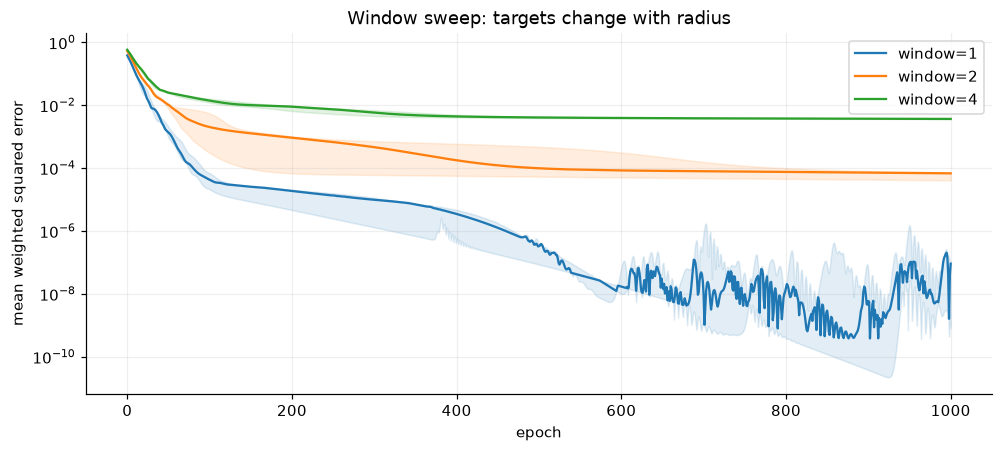

**Observed results.** `window=1`: mean final loss 6.470e-08 (seed SD 5.561e-08); `window=2`: mean final loss 6.051e-05 (seed SD 1.714e-05); `window=4`: mean final loss 3.650e-03 (seed SD 2.518e-05). Curves show the median and the full seed range, not confidence intervals.

,radius,context mass,observed cells,density
0,1,224.0,120,0.1038
1,2,388.0,186,0.1609
2,4,536.0,249,0.2154


In [18]:
window_results = sweep("window", CONFIG.window_grid)
window_summary = show_sweep(window_results, "Window sweep: targets change with radius")
window_stats = []
for radius in CONFIG.window_grid:
    counts = get_run(replace(CONFIG, window=radius))["X"]
    window_stats.append({"radius": radius, "context mass": counts.sum(),
                         "observed cells": int((counts > 0).sum()),
                         "density": float((counts > 0).mean())})
display(pd.DataFrame(window_stats))

**Interpretation.** Increasing the radius adds events and may connect previously
unobserved word pairs. In these short sentences, a large radius quickly approaches
sentence-level context. A lower loss at one radius does not make it the better window:
the observed set, log targets, and weights have changed. Look for changes in individual
neighbors and ranks, and check whether those changes persist across the three seeds.

**Knowledge check — pause here.** Why can we compare dimension-sweep reconstruction losses more directly than window-sweep losses?

**Answer**

Dimension changes model capacity while keeping the data and weights fixed. Window size changes the regression problem itself, including which pairs are observed and their target values.

## 16. Distance-Weighted Co-occurrences

Replace the uniform contribution of one event with

$$a_{tu}=\frac{1}{|u-t|}.$$

$t,u$ are target/context positions and $a_{tu}$ is the event's contribution. Distance
1 contributes 1; distance 2 contributes $1/2$; distance 3 contributes $1/3$.
Summing these contributions gives fractional $X_{ij}$. This is separate from $f(X_{ij})$:
distance weighting changes the statistics **before** optimization; $f$ weights a
regression error **after** the counts have been aggregated.

For `a b c` with radius 2, $X_{a,c}=1$ uniformly and $0.5$ with inverse distance.
The second log target is $\log(0.5)\approx-0.6931$, which is perfectly valid.

,a,b,c
a,0.0,1.0,1.0
b,1.0,0.0,1.0
c,1.0,1.0,0.0


,a,b,c
a,0.0,1.0,0.5
b,1.0,0.0,1.0
c,0.5,1.0,0.0


log of a fractional observed count: -0.6931471805599453


**Full inverse-distance matrix**

,a,berlin,capital,cat,cold,crown,dog,france,gas,germany,hot,ice,in,is,king,kingdom,likes,man,palace,paris,pet,plays,prince,princess,queen,rules,solid,steam,the,visits,water,wears,with,woman
a,0.0,0.5,2.0,0.5,0.0,4.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,8.0,1.0,0.0,0.0,2.0,0.0,0.5,2.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,2.0
berlin,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.5
capital,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
cat,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,4.5,0.0,0.0,0.0,1.0,0.0
cold,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
crown,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
dog,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,4.5,0.0,0.0,0.0,1.0,0.0
france,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
gas,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,1.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
germany,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


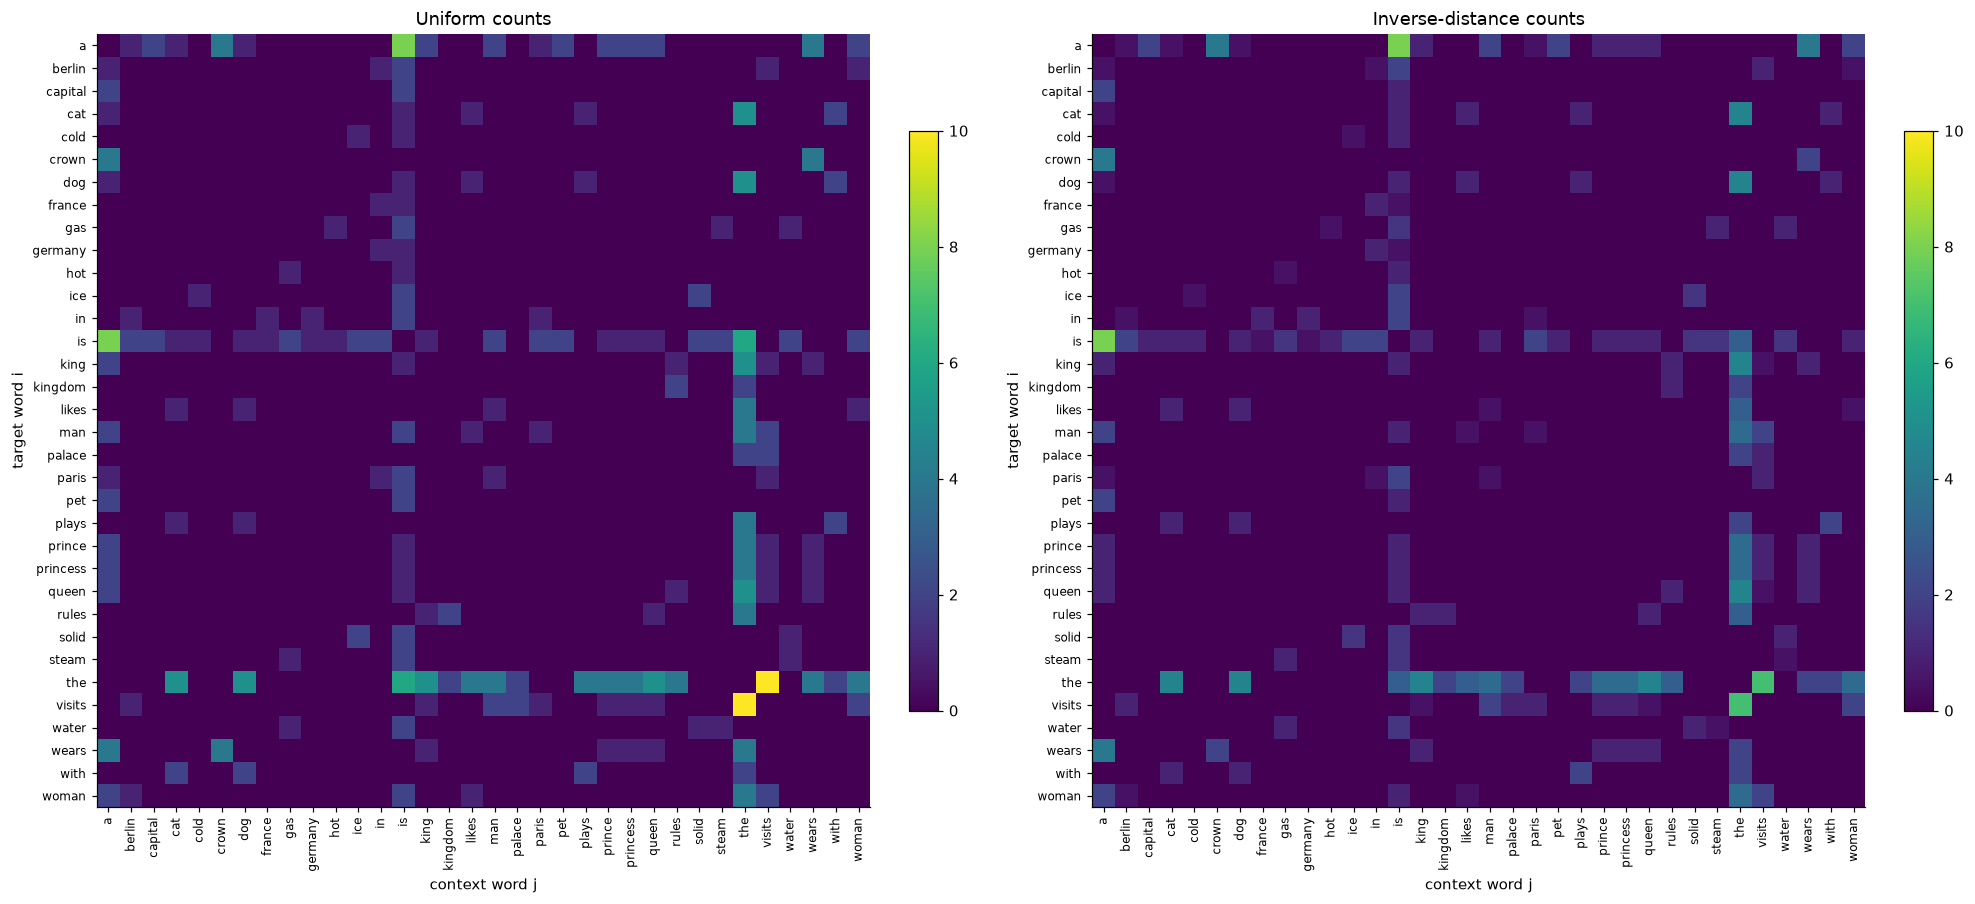

,mean_final_loss,std_final_loss,mean_weighted_RMSE,mean_late_loss_range,observed_pairs,parameters
distance_weighting,,,,,,
False,6.0513e-05,1.7145e-05,0.0111,4.8082e-06,186,204
True,1.4140e-03,3.3018e-04,0.0588,5.3792e-05,186,204


,distance_weighting,seed,initial J_mean,final J_sum,final J_mean,weighted RMSE,late loss range,upward steps,seconds,observed pairs,parameters
0,False,7,0.5227,0.0126,6.7999e-05,0.0118,3.7403e-06,8,0.2891,186,204
1,False,17,0.5242,0.0076,4.0899e-05,0.0092,2.2895e-06,23,0.2684,186,204
2,False,27,0.5228,0.0135,7.2643e-05,0.0122,8.3948e-06,0,0.2707,186,204
3,True,7,0.3527,0.2273,1.2221e-03,0.0549,4.0316e-05,39,0.2478,186,204
4,True,17,0.3558,0.3339,1.7953e-03,0.0665,6.5757e-05,0,0.2844,186,204
5,True,27,0.3541,0.2278,1.2247e-03,0.0549,5.5304e-05,21,0.3214,186,204


,distance_weighting,seed,query,top 3
0,False,7,king,"queen, capital, pet"
1,False,7,queen,"king, capital, pet"
2,False,7,paris,"berlin, solid, ice"
3,False,7,dog,"cat, ice, paris"
4,False,17,king,"queen, woman, man"
5,False,17,queen,"king, woman, man"
6,False,17,paris,"pet, berlin, a"
7,False,17,dog,"cat, visits, the"
8,False,27,king,"queen, prince, princess"
9,False,27,queen,"king, prince, princess"


,query,expected,top word,expected rank,status,distance_weighting,seed
0,king - man + woman,queen,queen,1,ranked,False,7
1,paris - france + germany,berlin,berlin,1,ranked,False,7
2,prince - man + woman,princess,princess,1,ranked,False,7
3,king - man + woman,queen,queen,1,ranked,False,17
4,paris - france + germany,berlin,palace,7,ranked,False,17
5,prince - man + woman,princess,princess,1,ranked,False,17
6,king - man + woman,queen,queen,1,ranked,False,27
7,paris - france + germany,berlin,berlin,1,ranked,False,27
8,prince - man + woman,princess,princess,1,ranked,False,27
9,king - man + woman,queen,queen,1,ranked,True,7


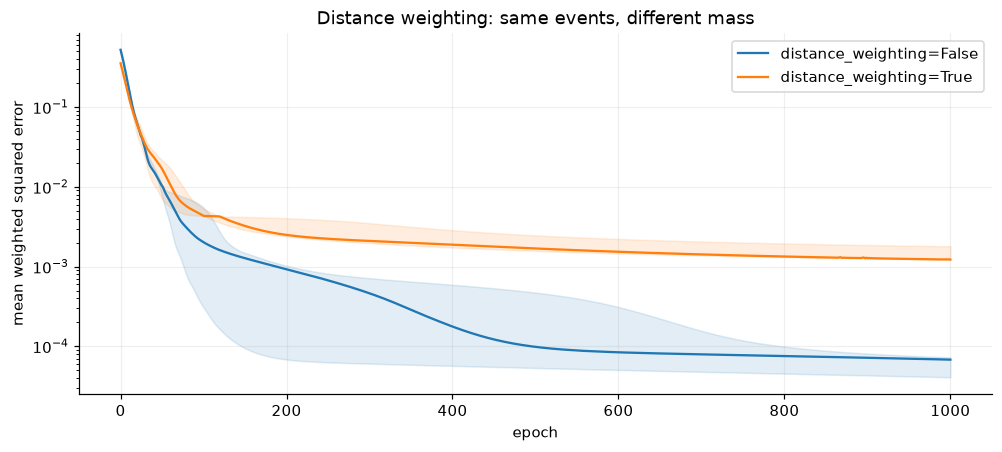

**Observed results.** `distance_weighting=False`: mean final loss 6.051e-05 (seed SD 1.714e-05); `distance_weighting=True`: mean final loss 1.414e-03 (seed SD 3.302e-04). Curves show the median and the full seed range, not confidence intervals.

In [19]:
distance_demo_ids = {"a": 0, "b": 1, "c": 2}
for weighted in (False, True):
    display(pd.DataFrame(build_cooccurrence([["a", "b", "c"]], distance_demo_ids, 2, weighted),
                         index=distance_demo_ids, columns=distance_demo_ids))
print("log of a fractional observed count:", np.log(0.5))
uniform_X = build_cooccurrence(sentences, word_to_id, CONFIG.window, False)
distance_X = build_cooccurrence(sentences, word_to_id, CONFIG.window, True)
display(Markdown("**Full inverse-distance matrix**"))
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(pd.DataFrame(distance_X, index=vocab, columns=vocab))
fig, axes = plt.subplots(1, 2, figsize=(18, 8), layout="constrained")
shared_max = max(uniform_X.max(), distance_X.max())
matrix_heatmap(uniform_X, vocab, "Uniform counts", ax=axes[0], vmin=0, vmax=shared_max)
matrix_heatmap(distance_X, vocab, "Inverse-distance counts", ax=axes[1], vmin=0, vmax=shared_max)
plt.show()
distance_results = sweep("distance_weighting", CONFIG.distance_grid)
distance_summary = show_sweep(distance_results, "Distance weighting: same events, different mass")

**Interpretation.** Both constructions observe the same pairs for a fixed corpus and
radius, but the fractional counts change targets and loss weights. A lower final
weighted error therefore cannot establish that one scheme learned better semantics.
When radius is 1 the two schemes are identical; at larger radii the inverse-distance
version gives immediate neighbors greater influence. Compare which neighbors and
analogy ranks move, not only the convergence curves.

## 17. Examine the Mathematics Numerically

Return to the baseline and inspect one **observed** word pair. Prefer king/rules when
it is present; for an edited corpus, use the first observed pair. The table exposes
every term of the fitted objective. These are learned values, unlike the invented
parameter example in Sections 6–9.

In [20]:
if {"king", "rules"}.issubset(word_to_id) and X[word_to_id["king"], word_to_id["rules"]] > 0:
    pair_i, pair_j = word_to_id["king"], word_to_id["rules"]
else:
    observed_i, observed_j, _ = observed_pairs(X)
    pair_i, pair_j = observed_i[0], observed_j[0]
actual_count = X[pair_i, pair_j]
actual_target = np.log(actual_count)
actual_dot = W[pair_i] @ W_context[pair_j]
actual_prediction = actual_dot + b[pair_i] + b_context[pair_j]
actual_error = actual_prediction - actual_target
actual_weight = float(weighting(actual_count, CONFIG.x_max, CONFIG.alpha))
display(pd.Series({"target word": vocab[pair_i], "context word": vocab[pair_j],
    "X_ij": actual_count, "log(X_ij) / target": actual_target,
    "w_i": W[pair_i], "w_tilde_j": W_context[pair_j], "dot product": actual_dot,
    "b_i": b[pair_i], "b_tilde_j": b_context[pair_j], "prediction": actual_prediction,
    "error (prediction - target)": actual_error, "weight": actual_weight,
    "weighted loss": actual_weight * actual_error ** 2}, name="one observed pair"))
display(Markdown(f"**Numerical reconstruction:** {actual_dot:.6f} + {b[pair_i]:.6f} + "
    f"{b_context[pair_j]:.6f} = {actual_prediction:.6f}. Subtract log({actual_count:g}) "
    f"= {actual_target:.6f}, square, and multiply by {actual_weight:.6f}: "
    f"the pair contributes **{actual_weight * actual_error ** 2:.8f}** to J."))

target word                                                            king
context word                                                          rules
X_ij                                                                    1.0
log(X_ij) / target                                                      0.0
w_i                                [0.2921379521585944, 1.5385572711797753]
w_tilde_j                      [-0.11335343768094443, -0.27989964709852994]
dot product                                                         -0.4638
b_i                                                                 -0.1244
b_tilde_j                                                            0.5882
prediction                                                             -0.0
error (prediction - target)                                            -0.0
weight                                                               0.2991
weighted loss                                                           0.0
Name: one ob

**Numerical reconstruction:** -0.463756 + -0.124443 + 0.588151 = -0.000048. Subtract log(1) = 0.000000, square, and multiply by 0.299070: the pair contributes **0.00000000** to J.

## 18. GloVe as Matrix Factorization

The full prediction matrix can be written

$$\widehat L=W\widetilde W^T+b\mathbf1^T+\mathbf1\tilde b^T.$$

$W,\widetilde W$ have shape $V\times d$; $b,\tilde b,\mathbf1$ are length-$V$
column vectors; $\mathbf1$ contains ones. The outer products broadcast target biases
across rows and context biases across columns. $\widehat L$ has shape $V\times V$.
The low-rank part $W\widetilde W^T$ has rank at most $d$; biases add at most two more.

For a $2\times1$ example, let $W=[1,2]^T$, $\widetilde W=[3,4]^T$,
$b=[0.1,0.2]^T$, and $\tilde b=[0.3,0.4]^T$. The cross product is
$[[3,4],[6,8]]$, and the biased prediction is $[[3.4,4.5],[6.5,8.6]]$.
NumPy broadcasting implements exactly this construction below.

Unlike ordinary truncated SVD, GloVe fits only observed log counts with entry-specific
weights and learned biases. Missing entries have no reconstruction penalty. A gray
cell below means **not observed**, whereas a real log-count zero corresponds to $X=1$.

Worked biased matrix:
 [[3.4 4.5]
 [6.5 8.6]]


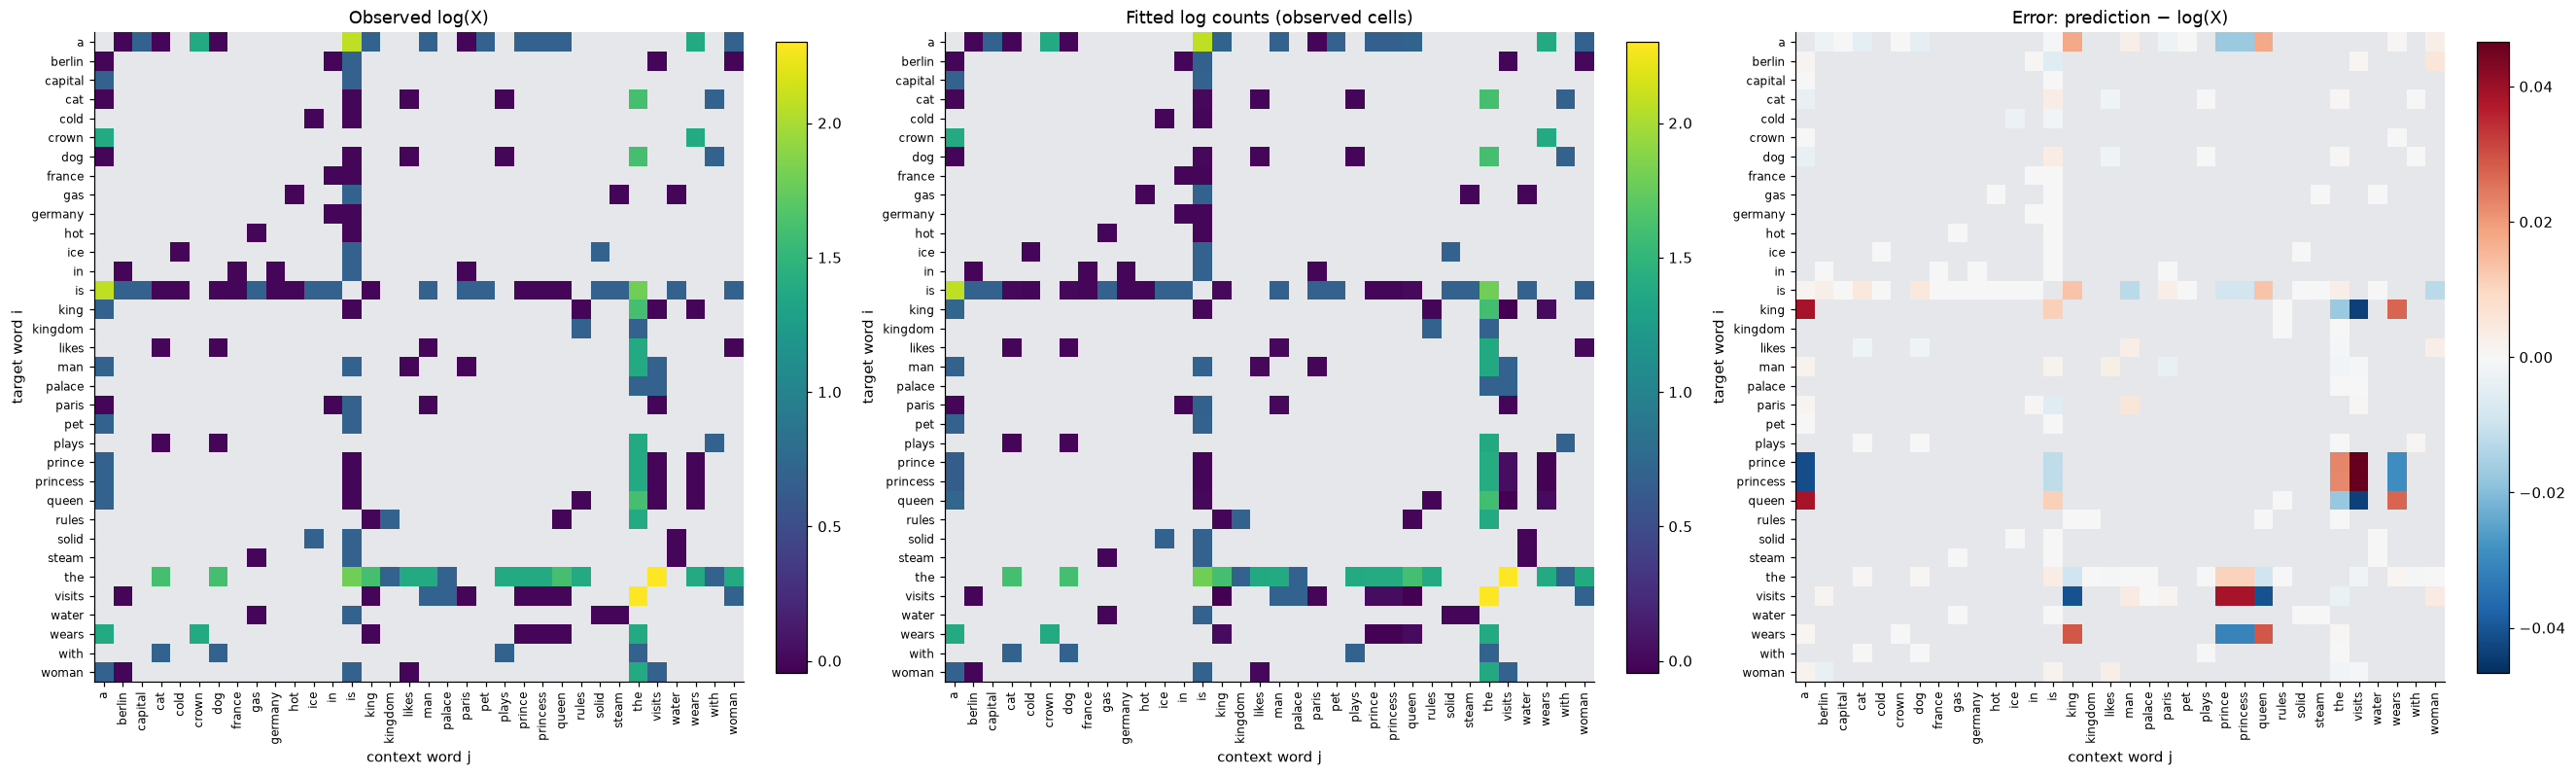

matrix-based J                   0.0126
training J                       0.0126
unweighted observed RMSE         0.0132
unconstrained missing cells    970.0000
dtype: float64

In [21]:
small_W, small_C = np.array([[1.], [2.]]), np.array([[3.], [4.]])
small_b, small_bc = np.array([0.1, 0.2]), np.array([0.3, 0.4])
print("Worked biased matrix:\n", small_W @ small_C.T + small_b[:, None] + small_bc[None, :])
observed = X > 0
log_X = np.full(X.shape, np.nan)
log_X[observed] = np.log(X[observed])
predicted_log_X = W @ W_context.T + b[:, None] + b_context[None, :]
visible_prediction = np.where(observed, predicted_log_X, np.nan)
reconstruction_error = visible_prediction - log_X
common_min = min(np.nanmin(log_X), np.nanmin(visible_prediction))
common_max = max(np.nanmax(log_X), np.nanmax(visible_prediction))
error_bound = max(np.nanmax(np.abs(reconstruction_error)), 1e-10)
fig, axes = plt.subplots(1, 3, figsize=(24, 8), layout="constrained")
matrix_heatmap(log_X, vocab, "Observed log(X)", ax=axes[0], vmin=common_min, vmax=common_max)
matrix_heatmap(visible_prediction, vocab, "Fitted log counts (observed cells)", ax=axes[1],
               vmin=common_min, vmax=common_max)
matrix_heatmap(reconstruction_error, vocab, "Error: prediction − log(X)", ax=axes[2],
               cmap="RdBu_r", vmin=-error_bound, vmax=error_bound)
plt.show()
reconstruction_J = np.sum(weighting(X[observed], CONFIG.x_max, CONFIG.alpha)
                           * reconstruction_error[observed] ** 2)
display(pd.Series({"matrix-based J": reconstruction_J, "training J": history.J_sum.iloc[-1],
                   "unweighted observed RMSE": np.sqrt(np.mean(reconstruction_error[observed] ** 2)),
                   "unconstrained missing cells": int((~observed).sum())}))

**Interpretation.** The matching loss calculations connect pairwise training to the
matrix view. Large residuals highlight observed relationships the chosen low-dimensional
model did not reconstruct closely. Missing cells are unconstrained by direct terms,
although their predictions share parameters with observed cells. They are masked to
avoid presenting untrained predictions as measured targets. Do not compare `E @ E.T`
with log counts: that is not the expression the optimizer fitted.

**Knowledge check — pause here.** Why does taking SVD of a zero-filled log-count matrix solve a different problem?

**Answer**

It treats missing cells as observed numerical zeros, omits GloVe's count-dependent weights and biases, and optimizes a different reconstruction loss. An observed log-count zero actually means a count of one.

## 19. Compare GloVe, LSA, and Skip-Gram

| Aspect | LSA | Skip-Gram | GloVe |
|---|---|---|---|
| Input statistics | Term-document counts or TF-IDF | Target/context token events | Aggregated word-word window counts |
| Local vs global | Global document statistics | Local training examples, shared parameters learn corpus-wide regularities | Local events aggregated into global statistics |
| Training objective | Low-rank squared reconstruction through SVD | Predict contexts; softmax or a surrogate such as negative sampling | Weighted squared errors on observed log counts |
| Matrix factorization | Explicit truncated SVD | SGNS has an implicit shifted-PMI connection under assumptions | Explicit parameterized low-rank log-count fit with biases |
| Context windows | Not needed for standard term-document LSA | Define positive target/context examples | Define entries accumulated in X |
| Computational strategy | Sparse or truncated SVD | Revisit token pairs and sample alternatives | Count once, then repeatedly optimize observed count entries |
| Embeddings produced | Term and document coordinates | Input/target and output/context vectors | Target/context vectors and biases; often sum vectors |
| Strengths | Simple global linear representation; familiar document retrieval pipeline | Efficient local training; flexible streaming of examples | Direct use of repeated-pair statistics; inspectable count objective |
| Weaknesses | Choice of weighting/rank matters; may miss linguistic offsets | Sampling and corpus order matter; repeated events cost work | Co-occurrence storage can be large; counts must be built; objective does not guarantee semantic geometry |

The three pipelines to remember:

* **LSA:** term-document matrix → truncated SVD → latent coordinates.
* **Skip-Gram:** target word → context prediction task → learned parameters.
* **GloVe:** word-word counts → weighted log-count regression → learned parameters.

“Predictive” versus “count-based” describes their training formulations, not mutually
exclusive kinds of linguistic information. SGNS also admits a matrix interpretation
under assumptions; see [Levy & Goldberg (2014)](https://papers.nips.cc/paper/5477-neural-word-embedding-as-implicit-matrix-factorization).
We compare objectives here rather than introducing two extra training systems.

## 20. Negative Sampling vs GloVe

Skip-Gram with Negative Sampling (SGNS) trains a binary discrimination objective.
For one positive pair $(i,j)$ and $K$ sampled noise contexts $n_1,\ldots,n_K$, its
minimized loss is

$$\ell_{SGNS}=-\log\sigma(w_i^T\tilde w_j)
-\sum_{r=1}^{K}\log\sigma(-w_i^T\tilde w_{n_r}),
\qquad \sigma(z)=\frac{1}{1+e^{-z}}.$$

$\sigma$ is the sigmoid, $z$ is a real score, $K$ is the number of noise samples,
and $n_r$ is the $r$th noise word drawn from a chosen distribution. Noise samples
are training labels, not proof that a pair is impossible; a sampled pair may have
appeared elsewhere in the corpus. SGNS is not a normalized context softmax.

For positive score 1 and one negative score −1, the loss is
$-\log\sigma(1)-\log\sigma(1)\approx0.626523$.
GloVe instead aggregates counts and penalizes their weighted log-reconstruction errors.
It does not need sampled negative pairs in its standard objective. Skipping $X=0$
is not equivalent to applying a negative label to those cells.

In [22]:
# Numerically stable -log(sigmoid(z)) = logaddexp(0, -z).
positive_score = 1.0
negative_scores = np.array([-1.0])
sgns_example = np.logaddexp(0, -positive_score) + np.logaddexp(0, negative_scores).sum()
display(pd.Series({"one-positive/one-negative SGNS loss": sgns_example,
                   "earlier GloVe pair loss": float(weighting(pair_x) * pair_error ** 2)}))

one-positive/one-negative SGNS loss    0.6265
earlier GloVe pair loss                0.0003
dtype: float64

**Interpretation.** These two values illustrate different equations, not a contest
between their magnitudes. SGNS distinguishes observed events from sampled noise;
GloVe asks whether one score reconstructs an aggregated log count. Both learn from
distributional regularities and both can fail to capture a relationship absent from data.

## 21. Scaling to Large Corpora

The dense implementation is for learning. A float32 stores four bytes, so a dense
$V\times V$ co-occurrence matrix alone requires

$$M=4V^2\text{ bytes}.$$

$V$ is vocabulary size and $M$ is storage. For $V=10{,}000$, this is
$4\times10^8=400{,}000{,}000$ bytes: 0.4 decimal GB or about 0.373 GiB.
A GB is $10^9$ bytes; a GiB is $2^{30}$ bytes. No large array is allocated below.
Our tutorial uses float64 for numerical checks, which would double these figures.

In [23]:
memory_rows = []
for vocabulary_size in (10_000, 50_000, 100_000, 1_000_000):
    bytes_required = 4 * vocabulary_size ** 2
    memory_rows.append({"vocabulary size": vocabulary_size, "bytes": bytes_required,
                        "GB (10^9 bytes)": bytes_required / 10**9,
                        "GiB (2^30 bytes)": bytes_required / 2**30})
display(pd.DataFrame(memory_rows))

,vocabulary size,bytes,GB (10^9 bytes),GiB (2^30 bytes)
0,10000,400000000,0.4,0.3725
1,50000,10000000000,10.0,9.3132
2,100000,40000000000,40.0,37.2529
3,1000000,4000000000000,4000.0,3725.2903


For billions of tokens, build a vocabulary in a counting pass, then stream sentences
with bounded context buffers. Accumulate observed pairs using sparse maps or blocks;
spill sorted runs to disk and merge duplicate pairs when RAM fills. Production systems
often use hybrid dense storage for frequent pairs and sparse/external storage for the
rest. Store pair triples $(i,j,X_{ij})$, not a $V^2$ array of mostly zeros. Storage is
proportional to observed pairs, but the number of observed pairs can itself be huge.

Train on shuffled triples in batches or with parallel updates to shared embedding rows.
Concurrent updates can race or change floating-point order, so parallel runs are less
strictly reproducible than this CPU example. Do not reuse this full-batch dense loop
unchanged at production scale. Matrix copies, sparse indices, embedding matrices,
gradients, and optimizer state need additional memory beyond the table above.

Window counting takes work proportional to token count times window radius. Each
training pass over observed triples takes work proportional to the number of triples
times embedding dimension. The [authors' implementation](https://github.com/stanfordnlp/GloVe)
separates vocabulary counting, co-occurrence construction, shuffling, and vector training.

## 22. Use Pretrained GloVe Embeddings

Pretrained vectors skip the counting and training stages: load a word-to-vector mapping
and use it for similarities or downstream features. The [official release page](https://nlp.stanford.edu/projects/glove/)
includes the classic Wikipedia 2014/Gigaword vectors and Common Crawl releases.
Their vocabulary casing and dimensions differ, so match token preprocessing to the
specific file. These are static type embeddings: a word has one vector across senses.

A standard GloVe text file has no header: each line contains a word followed by
floating-point coordinates. This loader streams lines and can retain only requested
words, avoiding a mandatory full-file allocation. It validates retained rows and
reports inconsistent dimensions or duplicates. `expected_dim` can enforce a known
release dimension. No external file is required: a clearly labeled toy fixture
exercises the exact same loader below.

In [24]:
def load_glove_text(path, wanted_words=None, expected_dim=None):
    """Load local headerless word/float rows; optionally retain only selected words."""
    if expected_dim is not None and (not isinstance(expected_dim, int) or expected_dim < 1):
        raise ValueError("expected_dim must be a positive integer or None")
    wanted = None if wanted_words is None else set(wanted_words)
    dimension = expected_dim
    vectors = {}
    with Path(path).open("r", encoding="utf-8") as source:
        for line_number, line in enumerate(source, start=1):
            fields = line.split()
            if not fields:
                continue
            word, components = fields[0], fields[1:]
            if wanted is not None and word not in wanted:
                continue
            try:
                vector = np.asarray(components, dtype=np.float32)
            except ValueError as exc:
                raise ValueError(f"Non-numeric retained row at line {line_number}") from exc
            if len(vector) == 0 or not np.all(np.isfinite(vector)):
                raise ValueError(f"Empty or non-finite retained vector at line {line_number}")
            if dimension is None:
                dimension = len(vector)
            if len(vector) != dimension:
                raise ValueError(f"Dimension mismatch at line {line_number}: expected {dimension}")
            if word in vectors:
                raise ValueError(f"Duplicate retained word at line {line_number}: {word}")
            vectors[word] = vector
    return vectors

with tempfile.TemporaryDirectory() as fixture_directory:
    fixture_path = Path(fixture_directory) / "toy_glove.txt"
    fixture_path.write_text("king 0.1 0.2 0.3\nqueen 0.2 0.1 0.4\ndog -0.1 0.4 0.2\n", encoding="utf-8")
    fixture_vectors = load_glove_text(fixture_path, wanted_words={"king", "queen"}, expected_dim=3)
display(Markdown("**Loader fixture only — these numbers are not pretrained GloVe vectors.**"))
display(pd.DataFrame.from_dict(fixture_vectors, orient="index", columns=["dim 1", "dim 2", "dim 3"]))

# Optional local-file usage: set a path only after obtaining a release yourself.
PRETRAINED_PATH = None  # Example: Path("/your/data/glove.6B.50d.txt")
if PRETRAINED_PATH is not None:
    pretrained = load_glove_text(PRETRAINED_PATH, wanted_words={"king", "queen", "paris", "dog"})
    print("Loaded words:", sorted(pretrained))
else:
    print("No pretrained path configured; all core notebook sections remain runnable offline.")

**Loader fixture only — these numbers are not pretrained GloVe vectors.**

,dim 1,dim 2,dim 3
king,0.1,0.2,0.3
queen,0.2,0.1,0.4


No pretrained path configured; all core notebook sections remain runnable offline.


## 23. Experiments

Return to the configuration in Section 2 to change corpus, vocabulary cap, radius,
dimension, learning rate, epochs, alpha, threshold, or distance weighting, then
restart/run all. The cache keys include the data and every training parameter so
previous baselines are reused only when identical. The following sweeps complete
the weighting comparisons started in Section 8; this is not a full Cartesian grid.

Keep experiment questions specific: “Does a larger dimension reduce reconstruction
error on the same matrix?” is answerable here. “Which setting learns the best English
semantics?” is not. All seed results are retained, including failed analogy prompts.

,mean_final_loss,std_final_loss,mean_weighted_RMSE,mean_late_loss_range,observed_pairs,parameters
alpha,,,,,,
0.50,5.9709e-05,1.5588e-05,0.0099,4.5867e-06,186,204
0.75,6.0513e-05,1.7145e-05,0.0111,4.8082e-06,186,204
1.00,4.9264e-05,1.9317e-05,0.0110,9.5029e-06,186,204


,alpha,seed,initial J_mean,final J_sum,final J_mean,weighted RMSE,late loss range,upward steps,seconds,observed pairs,parameters
0,0.50,7,0.5545,0.0097,5.2000e-05,0.0093,4.4485e-06,1,0.2498,186,204
1,0.50,17,0.5560,0.0092,4.9477e-05,0.0091,3.8618e-06,3,0.2513,186,204
2,0.50,27,0.5544,0.0144,7.7649e-05,0.0113,5.4499e-06,9,0.2717,186,204
3,0.75,7,0.5227,0.0126,6.7999e-05,0.0118,3.7403e-06,8,0.2891,186,204
4,0.75,17,0.5242,0.0076,4.0899e-05,0.0092,2.2895e-06,23,0.2684,186,204
5,0.75,27,0.5228,0.0135,7.2643e-05,0.0122,8.3948e-06,0,0.2707,186,204
6,1.00,7,0.4958,0.0087,4.6556e-05,0.0108,3.2198e-06,12,0.2449,186,204
7,1.00,17,0.4972,0.0058,3.1444e-05,0.0089,1.3804e-06,74,0.2457,186,204
8,1.00,27,0.4959,0.0130,6.9791e-05,0.0132,2.3909e-05,0,0.2498,186,204


,alpha,seed,query,top 3
0,0.50,7,king,"queen, paris, berlin"
1,0.50,7,queen,"king, paris, berlin"
2,0.50,7,paris,"berlin, pet, queen"
3,0.50,7,dog,"cat, pet, gas"
4,0.50,17,king,"queen, visits, princess"
5,0.50,17,queen,"king, visits, princess"
6,0.50,17,paris,"berlin, a, in"
7,0.50,17,dog,"cat, likes, prince"
8,0.50,27,king,"queen, kingdom, prince"
9,0.50,27,queen,"king, kingdom, prince"


,query,expected,top word,expected rank,status,alpha,seed
0,king - man + woman,queen,queen,1,ranked,0.50,7
1,paris - france + germany,berlin,steam,8,ranked,0.50,7
2,prince - man + woman,princess,princess,1,ranked,0.50,7
3,king - man + woman,queen,queen,1,ranked,0.50,17
4,paris - france + germany,berlin,capital,4,ranked,0.50,17
5,prince - man + woman,princess,princess,1,ranked,0.50,17
6,king - man + woman,queen,queen,1,ranked,0.50,27
7,paris - france + germany,berlin,berlin,1,ranked,0.50,27
8,prince - man + woman,princess,princess,1,ranked,0.50,27
9,king - man + woman,queen,queen,1,ranked,0.75,7


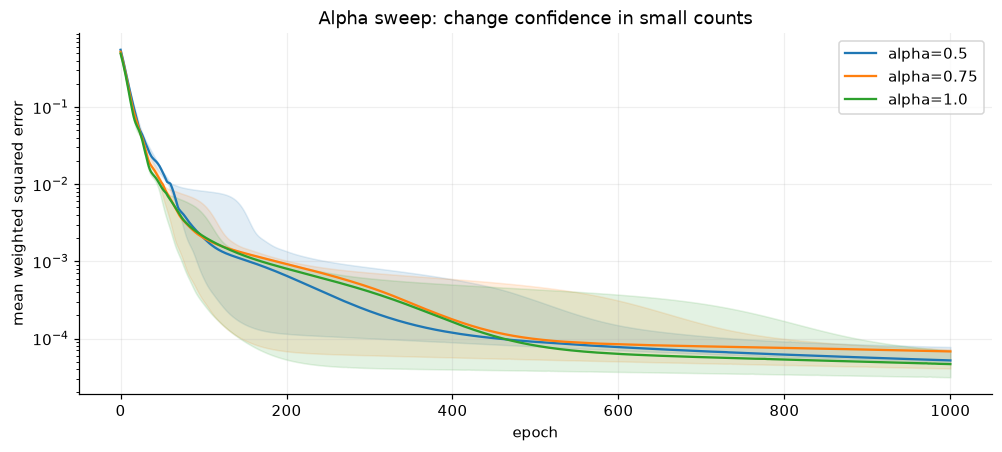

**Observed results.** `alpha=0.5`: mean final loss 5.971e-05 (seed SD 1.559e-05); `alpha=0.75`: mean final loss 6.051e-05 (seed SD 1.714e-05); `alpha=1.0`: mean final loss 4.926e-05 (seed SD 1.932e-05). Curves show the median and the full seed range, not confidence intervals.

,mean_final_loss,std_final_loss,mean_weighted_RMSE,mean_late_loss_range,observed_pairs,parameters
x_max,,,,,,
1.0,2.3164e-04,2.2333e-04,0.0141,2.0676e-05,186,204
5.0,6.0513e-05,1.7145e-05,0.0111,4.8082e-06,186,204
10.0,4.3965e-05,2.5206e-05,0.0119,1.5473e-05,186,204


,x_max,seed,initial J_mean,final J_sum,final J_mean,weighted RMSE,late loss range,upward steps,seconds,observed pairs,parameters
0,1.0,7,0.6374,0.0164,8.7970e-05,0.0094,5.5847e-06,23,0.2486,186,204
1,1.0,17,0.6390,0.0219,1.1800e-04,0.0109,8.1312e-06,84,0.2456,186,204
2,1.0,27,0.6370,0.0909,4.8894e-04,0.0221,4.8313e-05,40,0.2491,186,204
3,5.0,7,0.5227,0.0126,6.7999e-05,0.0118,3.7403e-06,8,0.2891,186,204
4,5.0,17,0.5242,0.0076,4.0899e-05,0.0092,2.2895e-06,23,0.2684,186,204
5,5.0,27,0.5228,0.0135,7.2643e-05,0.0122,8.3948e-06,0,0.2707,186,204
6,10.0,7,0.3484,0.0067,3.6009e-05,0.0110,2.7376e-06,2,0.2511,186,204
7,10.0,17,0.3492,0.0044,2.3697e-05,0.0089,1.3137e-06,52,0.2506,186,204
8,10.0,27,0.3489,0.0134,7.2189e-05,0.0156,4.2368e-05,0,0.2484,186,204


,x_max,seed,query,top 3
0,1.0,7,king,"queen, the, princess"
1,1.0,7,queen,"king, the, princess"
2,1.0,7,paris,"berlin, pet, wears"
3,1.0,7,dog,"cat, likes, visits"
4,1.0,17,king,"queen, solid, prince"
5,1.0,17,queen,"king, solid, prince"
6,1.0,17,paris,"berlin, capital, the"
7,1.0,17,dog,"cat, kingdom, likes"
8,1.0,27,king,"queen, cat, dog"
9,1.0,27,queen,"king, cat, dog"


,query,expected,top word,expected rank,status,x_max,seed
0,king - man + woman,queen,queen,1,ranked,1.0,7
1,paris - france + germany,berlin,cold,8,ranked,1.0,7
2,prince - man + woman,princess,princess,1,ranked,1.0,7
3,king - man + woman,queen,queen,1,ranked,1.0,17
4,paris - france + germany,berlin,the,3,ranked,1.0,17
5,prince - man + woman,princess,princess,1,ranked,1.0,17
6,king - man + woman,queen,queen,1,ranked,1.0,27
7,paris - france + germany,berlin,woman,7,ranked,1.0,27
8,prince - man + woman,princess,princess,1,ranked,1.0,27
9,king - man + woman,queen,queen,1,ranked,5.0,7


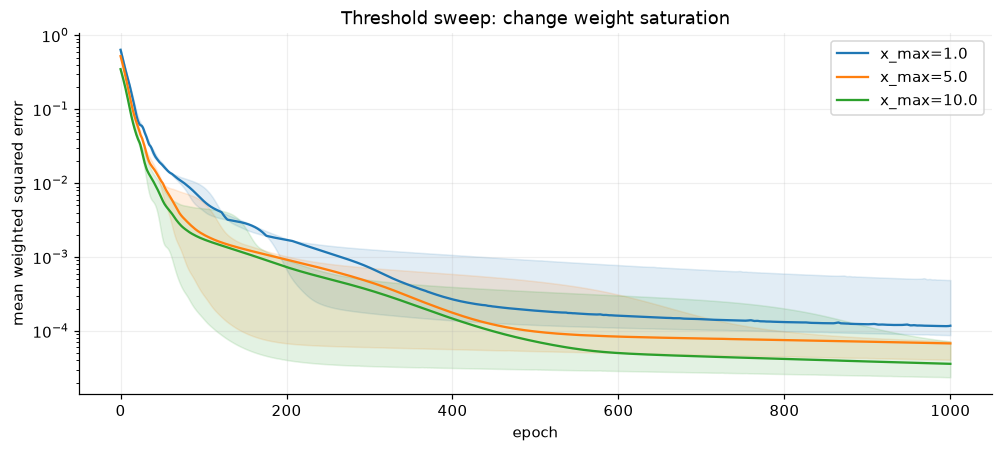

**Observed results.** `x_max=1.0`: mean final loss 2.316e-04 (seed SD 2.233e-04); `x_max=5.0`: mean final loss 6.051e-05 (seed SD 1.714e-05); `x_max=10.0`: mean final loss 4.396e-05 (seed SD 2.521e-05). Curves show the median and the full seed range, not confidence intervals.

In [25]:
alpha_results = sweep("alpha", CONFIG.alpha_grid)
alpha_summary = show_sweep(alpha_results, "Alpha sweep: change confidence in small counts")
xmax_results = sweep("x_max", CONFIG.x_max_grid)
xmax_summary = show_sweep(xmax_results, "Threshold sweep: change weight saturation")

**Interpretation.** Increasing alpha or x_max reduces the influence of some low counts.
The metric being optimized changes, so a reduced weighted loss can reflect reduced
weights rather than more accurate predictions. The weighted RMSE divides the summed
loss by total weight, removing a uniform weight scale, but still evaluates different
relative priorities when weights change nonuniformly. If every count is below both
thresholds at a fixed alpha, changing only x_max uniformly rescales the weights and
leaves the mathematical minimizers unchanged; finite optimizer trajectories may vary.
Use the neighbor and analogy tables to inspect consequences without claiming that
one weighted objective value ranks semantic quality.

In [26]:
all_sweeps = [dimension_results, window_results, distance_results, alpha_results, xmax_results]
experiment_rows, stability_rows = [], []
for result in all_sweeps:
    field = result["field"]
    for value, subset in result["metrics"].groupby(field, sort=False):
        candidates = [(val, run) for val, run in result["runs"] if val == value]
        ranks = result["analogies"].loc[result["analogies"][field] == value, "expected rank"].dropna()
        experiment_rows.append({"changed field": field, "value": str(value),
            "seeds": len(subset), "mean final loss": subset["final J_mean"].mean(),
            "SD final loss": subset["final J_mean"].std(),
            "mean probe rank (lower is better)": ranks.mean() if len(ranks) else np.nan,
            "available probe ranks": len(ranks), "mean seconds": subset.seconds.mean()})
        for query in ("king", "queen", "paris", "dog"):
            sets = [set(nearest(query, run, top_k=3).word) for _, run in candidates
                    if query in run["word_to_id"]]
            overlaps = [len(sets[a] & sets[b]) / len(sets[a] | sets[b])
                        for a in range(len(sets)) for b in range(a + 1, len(sets))
                        if sets[a] | sets[b]]
            if overlaps:
                stability_rows.append({"changed field": field, "value": str(value), "query": query,
                                       "mean top-3 seed Jaccard": np.mean(overlaps)})
experiment_summary = pd.DataFrame(experiment_rows)
neighbor_stability = pd.DataFrame(stability_rows)
display(experiment_summary)
display(neighbor_stability)
unique_training_seconds = sum(run["seconds"] for run in RUN_CACHE.values())
display(Markdown(f"**Run accounting:** {len(RUN_CACHE)} distinct training runs, "
    f"{unique_training_seconds:.1f} seconds in their optimization loops. Baseline rows "
    "appear in several summaries but were trained only once per seed. Table rendering, "
    "imports, and plots add time beyond this total."))

,changed field,value,seeds,mean final loss,SD final loss,mean probe rank (lower is better),available probe ranks,mean seconds
0,dimension,2,3,6.0513e-05,1.7145e-05,1.6667,9,0.2761
1,dimension,5,3,1.7619e-08,6.2284e-09,2.6667,9,0.2562
2,dimension,10,3,1.4457e-07,9.2612e-08,5.5556,9,0.2600
3,dimension,20,3,2.8214e-07,2.1722e-07,4.0000,9,0.2766
4,window,1,3,6.4702e-08,5.5615e-08,1.3333,9,0.2445
5,window,2,3,6.0513e-05,1.7145e-05,1.6667,9,0.2761
6,window,4,3,3.6497e-03,2.5180e-05,1.0000,9,0.2595
7,distance_weighting,False,3,6.0513e-05,1.7145e-05,1.6667,9,0.2761
8,distance_weighting,True,3,1.4140e-03,3.3018e-04,2.3333,9,0.2845
9,alpha,0.5,3,5.9709e-05,1.5588e-05,2.1111,9,0.2576


,changed field,value,query,mean top-3 seed Jaccard
0,dimension,2,king,0.2000
1,dimension,2,queen,0.2000
2,dimension,2,paris,0.2000
3,dimension,2,dog,0.2000
4,dimension,5,king,0.4667
5,dimension,5,queen,0.4667
6,dimension,5,paris,0.2000
7,dimension,5,dog,0.3000
8,dimension,10,king,0.1333
9,dimension,10,queen,0.1333


**Run accounting:** 33 distinct training runs, 8.6 seconds in their optimization loops. Baseline rows appear in several summaries but were trained only once per seed. Table rendering, imports, and plots add time beyond this total.

To interpret seed agreement, we use the Jaccard similarity of two top-three neighbor
sets $A,B$: $|A\cap B|/|A\cup B|$, where $|\cdot|$ is set size. One means identical
sets and zero means no shared neighbors. For `{queen, prince, crown}` and
`{queen, princess, crown}`, the intersection has 2 words and the union 4, so agreement
is $2/4=0.5$. Order is ignored; this measures repeatability of a small neighborhood,
not correctness. The table averages over all pairs of seeds.

In [27]:
neighbor_set_a = {"queen", "prince", "crown"}
neighbor_set_b = {"queen", "princess", "crown"}
print("Jaccard example:", len(neighbor_set_a & neighbor_set_b) / len(neighbor_set_a | neighbor_set_b))
if not neighbor_stability.empty:
    lowest = neighbor_stability.sort_values("mean top-3 seed Jaccard").iloc[0]
    display(Markdown(f"**An observed sensitivity:** `{lowest['changed field']}={lowest['value']}`, "
        f"query **{lowest['query']}**, has mean seed agreement "
        f"**{lowest['mean top-3 seed Jaccard']:.3f}**. Inspect its individual neighbor lists "
        "to see what changes. Stable neighbors can still be unhelpful; unstable neighbors "
        "warn against treating a single tiny run as a linguistic discovery."))

Jaccard example: 0.5


**An observed sensitivity:** `dimension=10`, query **queen**, has mean seed agreement **0.133**. Inspect its individual neighbor lists to see what changes. Stable neighbors can still be unhelpful; unstable neighbors warn against treating a single tiny run as a linguistic discovery.

## 24. Common Misconceptions

| Statement | Correction |
|---|---|
| “GloVe is just SVD.” | It optimizes an observed-entry weighted log-count loss with biases; standard SVD solves a different unweighted approximation problem. |
| “GloVe predicts words exactly like Word2Vec.” | Its direct target is a real-valued log count. Word2Vec has prediction-oriented formulations, including SGNS's binary discrimination task. |
| “The co-occurrence matrix itself is the embedding.” | A count row is a possible explicit representation, but the learned GloVe vector is a low-dimensional parameter vector. |
| “The target and context embeddings must be identical.” | They play different roles and are independently parameterized, even when the count matrix is symmetric. |
| “Larger embedding dimensions are always better.” | Extra capacity can fit a tiny observed matrix more closely without learning more useful semantic structure. |
| “GloVe only uses local context.” | Local windows define events; global aggregation supplies its training statistics. |
| “Zero co-occurrence entries should be passed into log directly.” | Select positive entries before taking logarithms. Missing counts are not log-count-zero targets. |
| “A low training loss proves the analogies work.” | The loss constrains cross dot products and biases, not the success of particular vector arithmetic prompts. |
| “Cosine similarity is a probability.” | It is a geometric score, can be negative, and does not sum to one over words. |
| “Count weighting makes squared error robust to all outliers.” | The multiplier depends on count, not residual size; a large error still incurs a quadratic penalty. |

## 25. Knowledge Checks

The earlier checks asked you to predict the next step. Now reconstruct the full
argument from memory. Answers appear in separate cells so you can pause first.

**Knowledge check — pause here.** What does X_ij represent? How does its interpretation change with inverse-distance weighting?

**Answer**

Uniform X_ij counts directed context events from i to j. With inverse-distance weighting it sums 1/distance for those same events and may be fractional.

**Knowledge check — pause here.** Why logarithms and a weighting function? Are they interchangeable?

**Answer**

Logarithms transform the regression target and encode multiplicative count changes additively. The weighting function determines how much each observed residual contributes. They serve different purposes.

**Knowledge check — pause here.** What happens to an unobserved pair? What about an observed count of exactly one?

**Answer**

An unobserved pair supplies no direct loss term. A count of one is observed and supplies log(1)=0 as a real target with positive weight.

**Knowledge check — pause here.** Why are there two embedding matrices, and where is their sum used?

**Answer**

One models target roles and the other context roles. Their cross dot products enter the loss. Their sum is an optional final representation used here for similarities and analogies.

**Knowledge check — pause here.** How does window size change X? Why is GloVe still called global?

**Answer**

A wider window admits more positional pairs, changing count mass and possibly support. Counts are aggregated over the entire corpus before training, making the fitting statistics global.

**Knowledge check — pause here.** In what sense is this matrix factorization, and why can low loss coexist with failed analogies?

**Answer**

The model approximates observed log counts with a low-rank cross product plus row/column biases. That criterion neither directly trains analogy answers nor uniquely determines the geometry of the combined embeddings.

**Executable checks.** These are small, independent correctness probes for the mechanics,
not tests requiring nice-looking semantic results. The central gradient check perturbs
one scalar parameter and compares the resulting loss difference with autodiff.

For a scalar coordinate $\theta$ and a small step $\epsilon$, the central difference
is $[J(\theta+\epsilon)-J(\theta-\epsilon)]/(2\epsilon)$, an approximation to
$\partial J/\partial\theta$. The table below evaluates it with $\epsilon=10^{-6}$
for the first target-vector coordinate and compares it to the exact autodiff value.

In [28]:
def expect_error(exception, action):
    """Assert that a malformed input raises its documented exception."""
    try:
        action()
    except exception:
        return
    raise AssertionError(f"Expected {exception.__name__}")

# Hand-computed radius-1 matrix for 'a b a'; repeated positions, directed counts.
ab_ids = {"a": 0, "b": 1}
ab = build_cooccurrence([["a", "b", "a"]], ab_ids, window=1)
np.testing.assert_array_equal(ab, [[0, 2], [2, 0]])
ab_radius2 = build_cooccurrence([["a", "b", "a"]], ab_ids, window=2)
np.testing.assert_array_equal(ab_radius2, [[2, 2], [2, 0]])
ab_weighted = build_cooccurrence([["a", "b", "a"]], ab_ids, window=2, distance_weighting=True)
np.testing.assert_array_equal(ab_weighted, [[1, 2], [2, 0]])
assert np.all(build_cooccurrence([["a"], ["b"]], ab_ids, window=4) == 0)
assert np.all(build_cooccurrence([["a", "excluded", "b"]], ab_ids, window=1) == 0)
np.testing.assert_array_equal(
    build_cooccurrence([["a", "excluded", "b"]], ab_ids, 2, True), [[0, 0.5], [0.5, 0]])
assert [len(list(context_pairs(example_tokens, r))) for r in (1, 2, 3)] == [8, 14, 18]
assert np.allclose(X, X.T)
assert np.allclose(distance_X, distance_X.T)
np.testing.assert_allclose(P[X.sum(axis=1) > 0].sum(axis=1), 1)
assert np.isnan(conditional_probabilities(np.zeros((2, 2)))).all()
assert np.isnan(probability_ratio(0, 0)[0]) and np.isinf(probability_ratio(1, 0)[0])
assert probability_ratio(0, 1)[0] == 0
np.testing.assert_allclose(weighting([0, 1, 5, 10]), [0, (1/5)**0.75, 1, 1])
assert weighting(1, 5, 1) < weighting(1, 5, 0.5)
assert build_vocabulary([["b", "a", "c"]], 2)[0] == ["a", "b"]
expect_error(ValueError, lambda: observed_pairs(np.zeros((2, 2))))
expect_error(ValueError, lambda: list(context_pairs(["a", "b"], 0)))

# Small loss problem with both an unobserved zero and a genuinely observed count of 1.
test_X = np.array([[0., 2.], [1., 0.]])
test_W = np.array([[0.2, -0.1], [0.3, 0.4]])
test_C = np.array([[0.5, 0.3], [-0.2, 0.1]])
test_b, test_bc = np.array([0.4, 0.2]), np.array([0.1, -0.1])
ti, tj, tx = observed_pairs(test_X)
assert len(tx) == 2 and np.isfinite(np.log(tx)).all() and 1 in tx
tW = torch.tensor(test_W, dtype=DTYPE, requires_grad=True)
tC = torch.tensor(test_C, dtype=DTYPE, requires_grad=True)
tb = torch.tensor(test_b, dtype=DTYPE, requires_grad=True)
tbc = torch.tensor(test_bc, dtype=DTYPE, requires_grad=True)
t_errors = (tW[ti] * tC[tj]).sum(dim=1) + tb[ti] + tbc[tj] - torch.tensor(np.log(tx), dtype=DTYPE)
torch_loss = (torch.tensor(weighting(tx), dtype=DTYPE) * t_errors.square()).sum()
numpy_loss = glove_loss_numpy(test_W, test_C, test_b, test_bc, test_X)
np.testing.assert_allclose(torch_loss.item(), numpy_loss, rtol=1e-12)
torch_loss.backward()
epsilon = 1e-6
plus, minus = test_W.copy(), test_W.copy()
plus[0, 0] += epsilon
minus[0, 0] -= epsilon
finite_difference = (glove_loss_numpy(plus, test_C, test_b, test_bc, test_X)
                     - glove_loss_numpy(minus, test_C, test_b, test_bc, test_X)) / (2 * epsilon)
np.testing.assert_allclose(tW.grad[0, 0].item(), finite_difference, rtol=1e-6, atol=1e-9)
analytic_bias_gradient = 2 * weighting(tx[0]) * t_errors.detach().numpy()[0]
np.testing.assert_allclose(tb.grad[0].item(), analytic_bias_gradient, rtol=1e-12)
np.testing.assert_allclose(reconstruction_J, history.J_sum.iloc[-1], rtol=1e-10)
assert np.isnan(cosine_similarity([0, 0], [1, 0]))
assert rank_vectors(np.zeros(2), np.eye(2), ["a", "b"]).empty
np.testing.assert_allclose(cosine_similarity([1, 0], [1, 1]), 1 / np.sqrt(2))
expect_error(KeyError, lambda: nearest("__not_in_vocabulary__"))
expect_error(KeyError, lambda: analogy("__not_in_vocabulary__", vocab[0], vocab[-1]))
for query_word in ("king", "queen", "paris", "dog"):
    if query_word in word_to_id:
        assert query_word not in set(nearest(query_word).word)
for a, b_word, c, _ in ANALOGIES:
    if {a, b_word, c}.issubset(word_to_id):
        _, ranking = analogy(a, b_word, c)
        assert not set(ranking.word) & {a, b_word, c}
assert set(fixture_vectors) == {"king", "queen"}
np.testing.assert_allclose(fixture_vectors["king"], [0.1, 0.2, 0.3])
with tempfile.TemporaryDirectory() as fixture_directory:
    malformed = Path(fixture_directory) / "bad.txt"
    malformed.write_text("a 0.1 0.2\nb 0.3\n", encoding="utf-8")
    expect_error(ValueError, lambda: load_glove_text(malformed))
    malformed.write_text("a nan 0.2\n", encoding="utf-8")
    expect_error(ValueError, lambda: load_glove_text(malformed))

for run in RUN_CACHE.values():
    assert np.isfinite(run["history"][["J_mean", "J_sum"]].to_numpy()).all()
    assert np.isfinite(run["vectors"]).all()
    # This assertion is about the shipped teaching experiment, not arbitrary edited settings.
    if CONFIG == Config():
        assert run["history"].J_mean.iloc[-1] < 0.5 * run["history"].J_mean.iloc[0]
repeated = train_glove(ab, dimension=2, epochs=5, seed=7)
repeated_again = train_glove(ab, dimension=2, epochs=5, seed=7)
np.testing.assert_array_equal(repeated["W"], repeated_again["W"])
display(pd.Series({"NumPy loss": numpy_loss, "PyTorch loss": torch_loss.item(),
                   "autodiff derivative": tW.grad[0, 0].item(),
                   "finite-difference derivative": finite_difference}, name="numerical verification"))
print("All context, masking, probability, loss, gradient, retrieval, loader, and training checks passed.")

NumPy loss                      0.1959
PyTorch loss                    0.1959
autodiff derivative             0.0892
finite-difference derivative    0.0892
Name: numerical verification, dtype: float64

All context, masking, probability, loss, gradient, retrieval, loader, and training checks passed.


## 26. Final Summary

```text
Raw text
  ↓
Tokenization (preserve sentence boundaries and positions)
  ↓
Vocabulary
  ↓
Context windows
  ↓
Word-word co-occurrence matrix X
  ↓
Observed counts → log targets and weights f(X_ij)
  ↓
Fit: w_iᵀ w_tilde_j + b_i + b_tilde_j ≈ log(X_ij)
  ↓
Gradient-based optimization of weighted squared errors
  ↓
Target + context embeddings
  ↓
Final word vectors
  ↓
Cosine similarity / semantic relationships
```

GloVe compresses an accumulated table of word-context relationships into shared
parameters. Logs make multiplicative count differences additive; biases handle
word-specific offsets; weights control the contribution of each observed residual.
Repeated gradient updates move vectors until their cross dot products and biases
reconstruct those statistics more closely. Similarities and offsets then become
things we can examine, not properties we should assume succeeded.

**GloVe learns word vectors so that their geometric relationships encode statistical
relationships found in global word co-occurrence data.**

You can now trace one sentence into count updates, one count into a loss and gradient,
and one trained vector into a neighbor or analogy query. For the next exploration,
change one configuration value, predict what it will affect, rerun, and compare that
prediction with the actual tables. Keep the distinction between fitting statistics
and learning useful semantics throughout.